# 07 — Tier D (stimulus descriptors) + Phase-1 Stage 4

**Scientific question (WORKFLOW §5 Stage 4).**
*Does explicit stimulus context — luminance, contrast, motion energy,
spatial- and temporal-frequency content, stimulus family — improve layer
decoding beyond the stimulus-locked neural response (A1) and reliability
(B) and behavioural modulation (C1) signals we already have? And: does
the trial-level path or the hash-level path win as the Phase-1 headline?*

**Stage 4 IS the conclusion of Phase 1.** Two paths competing for the
headline:

- **Trial-level** : A0 + C0 + D0 (per-(neuron, trial) rows, 4M).
- **Hash-level**  : A1 + B + C1 + D1 (per-(neuron, hash) rows, 1.21M).

Plus, at this Stage we bring back **DeepSets** (workflow §3.6 Strategy 3)
as the final headline test on the hash-level path. Notebook 04 showed
DeepSets > HGB on A1 amp+shape (0.584 vs 0.502); we want to know whether
that advantage compounds when the full A1+B+C1+D1 stack is given to it.

**Reads.**
- `data/processed/tables/units_working.parquet`
- `data/processed/features/A0_*.parquet`, `A1_*.parquet`
- `data/processed/features/B_per_hash.parquet`
- `data/processed/features/C0_per_trial.parquet`, `C1_per_hash.parquet`
- `data/processed/results/stage{1,2,3}_runs.parquet` (baseline reuse)
- the H5 `videos/<hash>/clip` arrays (read by `compute_tier_d`)

**Writes.**
- `data/processed/features/D_per_hash.parquet` (~2,411 rows × 13 features).
- `data/processed/results/stage4_runs.parquet` — every fitted Stage-4 cfg.
- `data/processed/results/stage4_ablation.parquet` — Δ tables.
- `data/processed/results/phase1_ablation.parquet` — combined Stages 1–4.
- `reports/figures/07_*.png`

## 1. Setup

In [1]:
from __future__ import annotations

import sys, time, gc, warnings
from pathlib import Path

if '..' not in sys.path:
    sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')

import microns_datacleaner as mic

from src.config import (
    PROCESSED_TABLES_DIR, PROCESSED_FEATURES_DIR, PROCESSED_SPLITS_DIR,
    PROCESSED_RESULTS_DIR, FIGURES_DIR, FUNCTIONAL_H5, DATA_DIR,
    RANDOM_SEED, ensure_dirs,
)
from src.data.loaders import (
    load_working_pop, load_splits, load_features, build_modeling_table,
)
from src.eval.metrics import neuron_level_score, summarize_cv_runs
from src.features.tier_b import B_FEATURE_NAMES
from src.features.tier_c import C0_FEATURE_NAMES, C1_FEATURE_NAMES
from src.features.tier_d import D_FEATURE_NAMES, compute_tier_d

ensure_dirs()
np.random.seed(RANDOM_SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

CLASSES = np.array(['L2/3', 'L4', 'L5', 'L6'])
N_FOLDS = 5

# Stim-family one-hot will be added to the D table at modelling time.
STIM_OHE = ['d_stim_Clip', 'd_stim_Monet2', 'd_stim_Trippy']
ALL_D_COLS = list(D_FEATURE_NAMES) + STIM_OHE

print('cwd               :', Path.cwd())
print('D numeric features:', D_FEATURE_NAMES)
print('D one-hot columns :', STIM_OHE)

cwd               : /Users/katiarusso/Documents/VS CODE/Classes/Neuroscience/Final Project
D numeric features: ('d_luminance_mean', 'd_luminance_std', 'd_contrast', 'd_motion_energy', 'd_sf_low', 'd_sf_mid', 'd_sf_high', 'd_tf_low', 'd_tf_mid', 'd_tf_high')
D one-hot columns : ['d_stim_Clip', 'd_stim_Monet2', 'd_stim_Trippy']


## Theory — stimulus descriptors and the Stage-4 question

Two facts of the recording shape this stage:

**(i) Stimulus descriptors are hash-level.** Every trial of the same
hash shows the same video, so the descriptors are determined entirely
by `condition_hash`. Unlike behaviour (which we had to handle via the
C0/C1 split because behaviour varies *across the trials of one hash*),
stimulus descriptors are constant per hash — no conditional-aggregation
machinery needed.

**(ii) D values are *not* session-correlated.** A hash's video content is
the same regardless of which session presents it. So per-session z-scoring
(which fixed Tier C1's diagnostic) doesn't degrade D's signal — D values
for the same hash are byte-identical across sessions.

### The same shared-feature structural argument as Tier C0 — but cleaner

Within a single hash, every neuron that saw it has the same D value. So
**D's univariate discriminative power across neurons within a hash is
zero** — same structural property as broadcast trial-level behaviour (C0).
Two consequences:

- **LogReg can use D only via main effects.** Different hashes have
  different D values; the model can learn coefficients that lean a
  prediction toward L4 when `d_motion_energy` is high *across rows that
  have that high motion-energy hash*. But within a session every neuron
  sees the same set of hashes, so D's main effect on layer is zero
  *within a session*. Across sessions, D's main effect on layer can
  emerge only via the same scan-composition mechanism that haunted Tier
  C0 — and per-session z-scoring de-confounds it.
- **HGB can use D via interactions with the neural channel** at depth
  ≥ 2. *'For high-luminance hashes, neurons with high amp_peak tend to
  be L4'* is a real biological hypothesis, structurally inexpressible in
  a linear projection, naturally captured in a depth-2 tree split.

### Where D is *better* than C0 was — the scan-confound is weaker

C0's biggest worry was that broadcast behaviour scalars are correlated
with session identity (different mice / different days have different
behavioural distributions). D doesn't share that worry: a hash's video
content is fixed. **The only mechanism by which D could leak session
information is the asymmetry between the 116 oracle hashes (shared
across all sessions) and the ~164 session-private hashes per session.**
Per-session z-scoring still cleans this up.

### Why the *neuroscience* says D should help

Different cortical layers have different stimulus preferences:

- **L4** receives direct LGN input, has sharp tuning, prefers
  high-contrast localized stimuli; LGN neurons are bandpass with peaks
  in the mid spatial-frequency range.
- **L2/3** integrates over context, has broader receptive fields and
  longer-range horizontal connectivity; responds well to natural scenes
  with rich SF/TF content.
- **L5** is a mix (IT + ET + NP subtypes) — large pyramidal cells that
  often have transient responses to motion onset.
- **L6** has narrow tuning, low spontaneous rates, and the most sustained
  response profiles.

These layer-specific preferences are real. The question Stage 4 asks is
whether they're recoverable from explicit stimulus descriptors *given*
we already have the trial-averaged neural response (A1) which has
implicitly absorbed the response-to-stimulus relationship.

### The Stage-4 prediction structure

- **HGB on A1+B+D1 should help modestly** — D1 lets the tree condition
  on stimulus type (Clip vs Monet2 vs Trippy) and stimulus content,
  enabling family-specific decision rules.
- **LogReg on A1+B+D1 should help slightly** via main-effect leakage
  (same scan-correlated structure mechanism as Tier C). The Δ between
  raw and zscored deltas is the diagnostic.
- **Per-class Δ is hard to predict cleanly** — the literature gives us
  expectations for layer-specific stimulus tuning but at the level of
  cell types and detailed stimulus parameters that we deliberately
  excluded (no orientation features). Reportable findings here are
  empirical, not strong predictions.
- **DeepSets on the full stack may set the Phase-1 headline.** The
  per-row encoder has 30+ features per row to combine; mean-pooling over
  the neuron's ~280 rows aggregates richly.

### What we explicitly do NOT compute

WORKFLOW §3.5 binding rule: no orientation/direction features, even when
the stimulus is a Monet2 grating with a known direction. `pref_ori`,
`pref_dir`, `gOSI`, `gDSI`, and any orientation- or direction-selectivity
scalar are out of scope for the entire project. Tier D's spatial-
frequency descriptors are *power summaries* over radial bands — they
don't preserve orientation information.

## 3. Compute Tier D (per-`condition_hash` stimulus descriptors)

Iterate over the 2,411 unique condition hashes, read each video from the
H5, compute the 10 numeric descriptors (luminance, contrast, motion
energy, SF/TF banded power) plus the categorical `stim_type`. Save to
`D_per_hash.parquet`. The cell is idempotent — if the parquet exists it
is loaded.

Expected wall time: 2–8 min depending on disk speed (the dominant cost
is reading uint8 video arrays from the H5).

In [2]:
D_PATH = PROCESSED_FEATURES_DIR / 'D_per_hash.parquet'

if D_PATH.exists():
    print(f'Tier D cache exists at {D_PATH}; loading.')
    d = pd.read_parquet(D_PATH)
else:
    print('Computing Tier D from H5 (this is a one-time pass over the videos) …')
    reader = mic.MicronsFunctionalReader(datadir=str(DATA_DIR), path=str(FUNCTIONAL_H5))
    # Collect every unique hash across the three stim families.
    all_hashes: list[str] = []
    for fam in ['Clip', 'Monet2', 'Trippy']:
        hs = list(reader.get_hashes_by_type(fam))
        hs = [h.decode() if isinstance(h, (bytes, bytearray)) else str(h) for h in hs]
        all_hashes.extend(hs)
    print(f'Total hashes to process: {len(all_hashes):,}')
    t0 = time.time()
    d = compute_tier_d(reader, all_hashes, progress_every=200)
    print(f'  done in {time.time()-t0:.1f}s; shape {d.shape}')
    d.to_parquet(D_PATH, compression='zstd')
    print(f'saved: {D_PATH}')

print()
print('D head:')
print(d.head(3).to_string())
print()
print('describe (numeric):')
print(d[list(D_FEATURE_NAMES)].describe(percentiles=[0.05, 0.5, 0.95]).round(3).to_string())
print()
print('count by stim_type:')
print(d['stim_type'].value_counts())

Tier D cache exists at data/processed/features/D_per_hash.parquet; loading.

D head:
         condition_hash stim_type  n_frames  frame_height  frame_width  d_luminance_mean  d_luminance_std  d_contrast  d_motion_energy  d_sf_low  d_sf_mid  d_sf_high  d_tf_low  d_tf_mid  d_tf_high
0  /0MJJl6hCzFo3gxCJSmv      Clip        75           144          256          0.565160         0.178520    0.315876         0.074521  0.994288  0.005042   0.000670  0.989451  0.007292   0.003257
1  /3cVqNzav4cRdcLPJXWr      Clip        75           144          256          0.311339         0.216292    0.694713         0.008369  0.981284  0.015549   0.003167  0.995263  0.002621   0.002116
2  /5KYggaBDxG7uxMGf589      Clip        75           144          256          0.199283         0.118574    0.595001         0.048810  0.991928  0.006392   0.001679  0.956566  0.028796   0.014639

describe (numeric):
       d_luminance_mean  d_luminance_std  d_contrast  d_motion_energy  d_sf_low  d_sf_mid  d_sf_high  d_tf

## 4. Per-family D distributions — sanity by stimulus family

We expect:
- **Clip** (natural movies): broad SF/TF distribution, real motion energy.
- **Monet2** (drifting bars): peaked SF (single dominant grating freq),
  high motion energy.
- **Trippy** (phase-shuffled noise): broad SF (random), low motion if
  static-by-frame, high if phase-cycling.

If Clip-Monet2-Trippy clearly separate in the violin plots, the D
features are picking up real stimulus-content differences. If they don't,
either the descriptors are too coarse or the stimulus families are more
similar than expected.

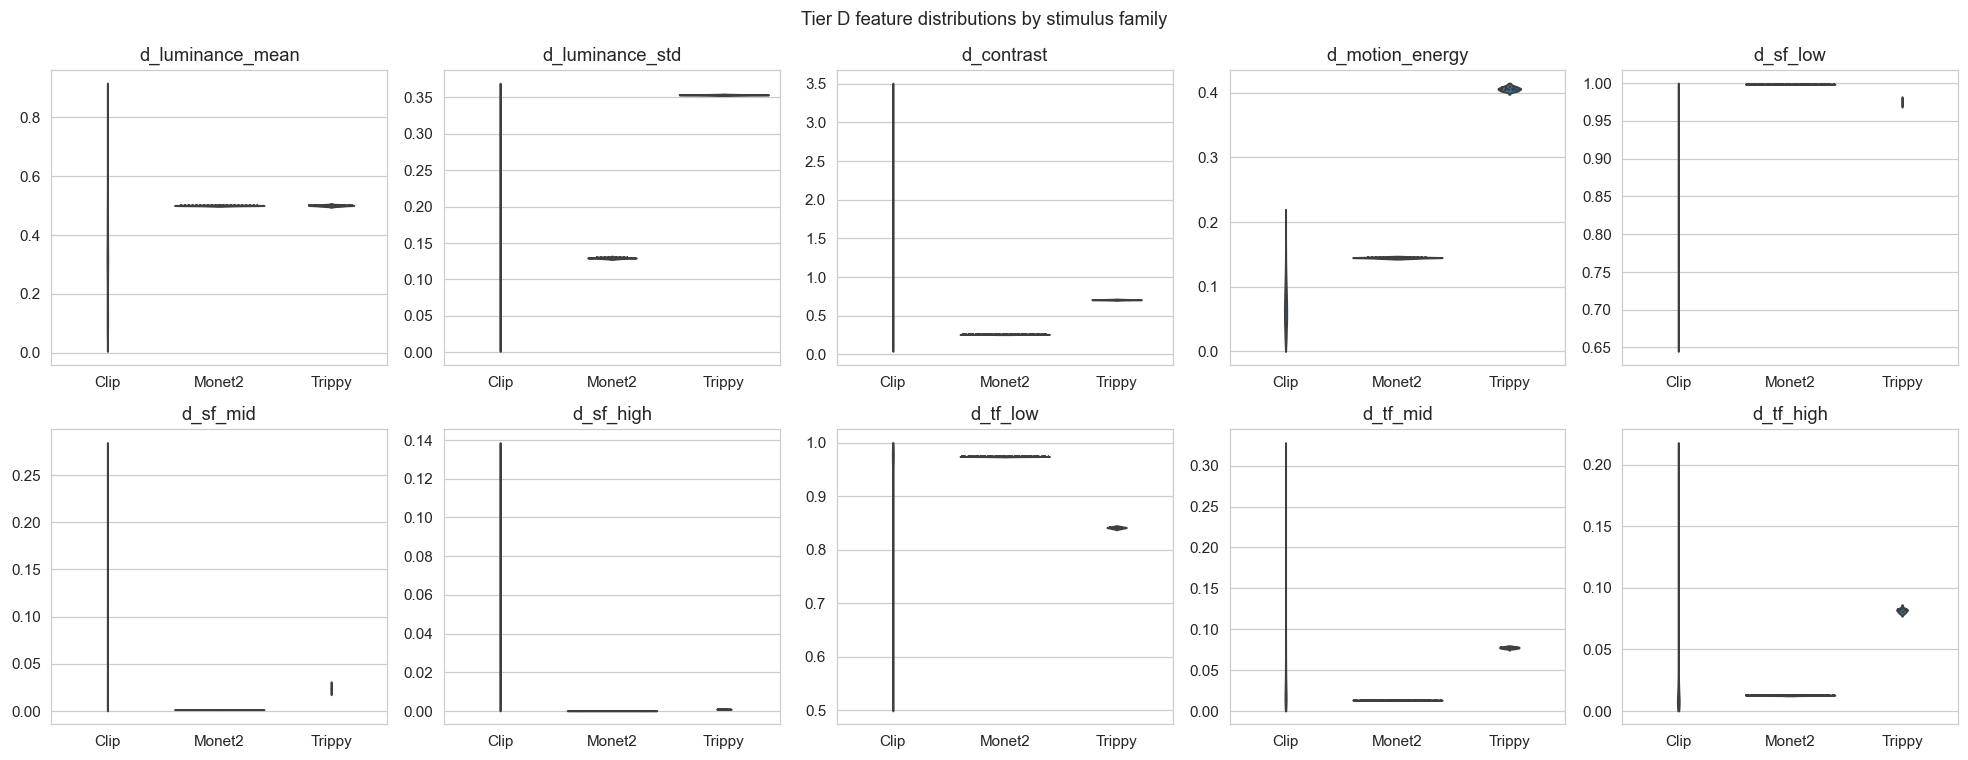

Median D feature by stim_type:
stim_type          Clip  Monet2  Trippy
d_luminance_mean  0.310   0.500   0.500
d_luminance_std   0.180   0.129   0.354
d_contrast        0.655   0.259   0.707
d_motion_energy   0.066   0.145   0.406
d_sf_low          0.987   0.999   0.975
d_sf_mid          0.011   0.001   0.024
d_sf_high         0.002   0.000   0.001
d_tf_low          0.965   0.974   0.841
d_tf_mid          0.024   0.013   0.078
d_tf_high         0.011   0.013   0.082


In [3]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, feat in zip(axes.flat, D_FEATURE_NAMES):
    sns.violinplot(data=d, x='stim_type', y=feat,
                   order=['Clip', 'Monet2', 'Trippy'],
                   inner='quartile', cut=0, ax=ax)
    ax.set_title(feat); ax.set_xlabel(''); ax.set_ylabel('')
plt.suptitle('Tier D feature distributions by stimulus family')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_tierD_violins_by_family.png', dpi=130)
plt.show()

print('Median D feature by stim_type:')
print(d.groupby('stim_type')[list(D_FEATURE_NAMES)].median().round(3).T)

## 5. Stage-4 modelling helpers + checkpointing

Same `make_pipeline_for` / `cv_fit_score` / `per_session_zscore` pattern
as notebooks 05/06. Results are checkpointed to
`data/processed/results/stage4_runs.parquet`. On rerun, configurations
already in the parquet print SKIP and are not re-fit.

In [4]:
def make_pipeline_for(model_name: str):
    if model_name == 'LogReg':
        return Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale',  RobustScaler()),
            ('clf',    LogisticRegression(
                penalty='l2', C=1.0, solver='lbfgs',
                max_iter=400, class_weight='balanced', n_jobs=-1)),
        ])
    if model_name == 'HGB':
        return Pipeline([
            ('clf', HistGradientBoostingClassifier(
                max_iter=100, max_depth=8, learning_rate=0.05,
                l2_regularization=1.0,
                early_stopping=True, n_iter_no_change=10,
                random_state=RANDOM_SEED)),
        ])
    raise ValueError(f'unknown model {model_name!r}')


def per_session_zscore(X: np.ndarray, sessions: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64).copy()
    out = np.full_like(X, np.nan)
    for sk in np.unique(sessions):
        mask = sessions == sk
        Xs = X[mask]
        med = np.nanmedian(Xs, axis=0)
        mad = np.nanmedian(np.abs(Xs - med), axis=0)
        scale = np.where(mad > 1e-9, 1.4826 * mad, 1.0)
        out[mask] = (Xs - med) / scale
    return out


def cv_fit_score(X, y, groups, folds, model_name):
    fold_scores = []
    for k in range(N_FOLDS):
        tr = folds != k; te = folds == k
        pipe = make_pipeline_for(model_name)
        if model_name == 'HGB':
            sw = compute_sample_weight('balanced', y[tr])
            pipe.fit(X[tr], y[tr], clf__sample_weight=sw)
        else:
            pipe.fit(X[tr], y[tr])
        probs = pipe.predict_proba(X[te])
        fold_scores.append(neuron_level_score(y[te], probs, groups[te], pipe.classes_))
    return summarize_cv_runs(fold_scores)


RESULTS_PATH = PROCESSED_RESULTS_DIR / 'stage4_runs.parquet'
results_rows: list[dict] = []

def _save_results():
    pd.DataFrame(results_rows).to_parquet(RESULTS_PATH)

def _make_done_keys() -> set:
    return {(r['comparison'], r['preprocessing'], r['features'], r['model'])
            for r in results_rows}

if RESULTS_PATH.exists():
    existing = pd.read_parquet(RESULTS_PATH).to_dict(orient='records')
    in_mem = {(r['comparison'], r['preprocessing'], r['features'], r['model'])
              for r in results_rows}
    for r in existing:
        k = (r['comparison'], r['preprocessing'], r['features'], r['model'])
        if k not in in_mem:
            results_rows.append(r)
    print(f'Loaded {len(existing)} existing rows from {RESULTS_PATH.name}.')

# One-hot encoded D table for joining.
d_for_join = d.copy()
for fam in ['Clip', 'Monet2', 'Trippy']:
    d_for_join[f'd_stim_{fam}'] = (d_for_join['stim_type'] == fam).astype(np.float32)
d_for_join = d_for_join[['condition_hash'] + ALL_D_COLS].copy()
print(f'D one-hot table prepared: {d_for_join.shape}')

Loaded 14 existing rows from stage4_runs.parquet.
D one-hot table prepared: (2411, 14)


## 6. Hash-level path — A1+B+C1 vs A1+B+C1+D1

**Reuses A1+B+C1 baselines from Stage 3** (`stage3_runs.parquet`,
`comparison='A1+B vs A1+B+C1'` rows with `features='A1+B+C1'`). Adds D1
to the same long table and fits HGB and LogReg in raw + zscored variants.

In [5]:
# --- Step 1: copy A1+B+C1 baselines from Stage 3 -------------------------
stage3 = pd.read_parquet(PROCESSED_RESULTS_DIR / 'stage3_runs.parquet')
abc1_baselines = stage3[
    (stage3['comparison'] == 'A1+B vs A1+B+C1') &
    (stage3['features'] == 'A1+B+C1')
].copy()
print(f'Found {len(abc1_baselines)} A1+B+C1 baselines in stage3_runs.parquet:')
print(abc1_baselines[['model', 'preprocessing', 'balanced_accuracy',
                      'macro_f1']].round(3).to_string())

done_keys = _make_done_keys()
n_added = 0
for _, row in abc1_baselines.iterrows():
    key = ('A1+B+C1 vs A1+B+C1+D1', row['preprocessing'], 'A1+B+C1', row['model'])
    if key in done_keys:
        continue
    results_rows.append({
        'comparison': 'A1+B+C1 vs A1+B+C1+D1',
        'preprocessing': row['preprocessing'],
        'rows': int(row['rows']),
        'features': 'A1+B+C1',
        'model': row['model'],
        'balanced_accuracy':     row['balanced_accuracy'],
        'balanced_accuracy_std': row['balanced_accuracy_std'],
        'macro_f1':              row['macro_f1'],
        'macro_f1_std':          row['macro_f1_std'],
        'recall_L2/3': row['recall_L2/3'], 'recall_L4': row['recall_L4'],
        'recall_L5':   row['recall_L5'],   'recall_L6': row['recall_L6'],
    })
    done_keys.add(key)
    n_added += 1
if n_added:
    _save_results()
    print(f'Reused {n_added} A1+B+C1 baseline rows.')

# --- Step 2: which A1+B+C1+D1 fits still need running? ------------------
needed = [(prep, m) for prep in ['raw', 'zscored-by-session']
                    for m in ['LogReg', 'HGB']
                    if ('A1+B+C1 vs A1+B+C1+D1', prep, 'A1+B+C1+D1', m) not in done_keys]
if not needed:
    print()
    print('All A1+B+C1+D1 fits already in stage4_runs.parquet. Skipping data prep.')
    df_full_hash = None  # don't need it
else:
    print()
    print(f'Need to fit A1+B+C1+D1 for: {needed}')
    X_a1, y_a1, g_a1, f_a1, df_a1 = build_modeling_table(
        level='A1', blocks=['amp', 'shape'])
    b_hash = pd.read_parquet(
        PROCESSED_FEATURES_DIR / 'B_per_hash.parquet',
        columns=['nucleus_id', 'condition_hash'] + list(B_FEATURE_NAMES))
    df_a1b = df_a1.merge(b_hash, on=['nucleus_id', 'condition_hash'],
                         how='inner', validate='one_to_one')
    c1 = pd.read_parquet(PROCESSED_FEATURES_DIR / 'C1_per_hash.parquet',
        columns=['nucleus_id', 'condition_hash'] + list(C1_FEATURE_NAMES))
    df_a1bc1 = df_a1b.merge(c1, on=['nucleus_id', 'condition_hash'],
                            how='left', validate='one_to_one')
    df_full_hash = df_a1bc1.merge(d_for_join, on='condition_hash',
                                  how='left', validate='many_to_one')
    print(f'A1 ∩ B + C1 + D1 table: {df_full_hash.shape}')

    feat_a1     = [c for c in df_full_hash.columns if c.startswith(('amp_', 'shape_'))]
    feat_abc1d1 = feat_a1 + list(B_FEATURE_NAMES) + list(C1_FEATURE_NAMES) + ALL_D_COLS
    y_h  = df_full_hash['layer_label'].to_numpy()
    g_h  = df_full_hash['nucleus_id'].to_numpy()
    f_h  = df_full_hash['gkf_fold'].to_numpy().astype(np.int8)
    sessions_h = df_full_hash['session_key'].to_numpy()
    X_full     = df_full_hash[feat_abc1d1].to_numpy(dtype=np.float64)
    X_full_zs  = per_session_zscore(X_full, sessions_h)
    print('per-session z-scoring computed.')

    print()
    print('=== Hash-level: A1+B+C1+D1 fits ===')
    for prep_label, X in [('raw', X_full), ('zscored-by-session', X_full_zs)]:
        for model_name in ['LogReg', 'HGB']:
            if (prep_label, model_name) not in needed:
                continue
            t0 = time.time()
            s = cv_fit_score(X, y_h, g_h, f_h, model_name)
            results_rows.append({
                'comparison': 'A1+B+C1 vs A1+B+C1+D1',
                'preprocessing': prep_label,
                'rows': len(X), 'features': 'A1+B+C1+D1',
                'model': model_name,
                'balanced_accuracy': s['balanced_accuracy'],
                'balanced_accuracy_std': s['balanced_accuracy_std'],
                'macro_f1': s['macro_f1'],
                'macro_f1_std': s['macro_f1_std'],
                **{f'recall_{c}': s['per_class_recall'].get(c) for c in ['L2/3','L4','L5','L6']},
            })
            done_keys.add(('A1+B+C1 vs A1+B+C1+D1', prep_label, 'A1+B+C1+D1', model_name))
            _save_results()
            print(f'  [{model_name:<6}, {prep_label:<18}] A1+B+C1+D1  '
                  f'bal_acc={s["balanced_accuracy"]:.3f} ± '
                  f'{s["balanced_accuracy_std"]:.3f} | macro_f1={s["macro_f1"]:.3f} | {time.time()-t0:.1f}s | saved')

Found 4 A1+B+C1 baselines in stage3_runs.parquet:
     model       preprocessing  balanced_accuracy  macro_f1
8   LogReg                 raw              0.433     0.337
9      HGB                 raw              0.576     0.443
10  LogReg  zscored-by-session              0.414     0.340
11     HGB  zscored-by-session              0.635     0.508

All A1+B+C1+D1 fits already in stage4_runs.parquet. Skipping data prep.


## 7. Trial-level path — A0+C0 vs A0+C0+D0

**Reuses A0+C0 baselines from Stage 3** (`stage3_runs.parquet`,
`comparison='A0 vs A0+C0'` rows with `features='A0 + C0'`). Adds D0 to
the same trial-level table and fits HGB + LogReg, raw only (the A0
table is large — zscoring is in Section 9b's sanity for A0+C0; we
extend that diagnostic to A0+C0+D0 only if the raw run is interesting).

In [6]:
# --- Step 1: copy A0+C0 baselines from Stage 3 ---------------------------
ac0_baselines = stage3[
    (stage3['comparison'] == 'A0 vs A0+C0') &
    (stage3['features'] == 'A0 + C0') &
    (stage3['preprocessing'] == 'raw')
].copy()
print(f'Found {len(ac0_baselines)} A0+C0 raw baselines:')
print(ac0_baselines[['model', 'balanced_accuracy', 'macro_f1']].round(3).to_string())

done_keys = _make_done_keys()
n_added = 0
for _, row in ac0_baselines.iterrows():
    key = ('A0+C0 vs A0+C0+D0', 'raw', 'A0+C0', row['model'])
    if key in done_keys:
        continue
    results_rows.append({
        'comparison': 'A0+C0 vs A0+C0+D0',
        'preprocessing': 'raw',
        'rows': int(row['rows']),
        'features': 'A0+C0',
        'model': row['model'],
        'balanced_accuracy': row['balanced_accuracy'],
        'balanced_accuracy_std': row['balanced_accuracy_std'],
        'macro_f1': row['macro_f1'], 'macro_f1_std': row['macro_f1_std'],
        'recall_L2/3': row['recall_L2/3'], 'recall_L4': row['recall_L4'],
        'recall_L5':   row['recall_L5'],   'recall_L6': row['recall_L6'],
    })
    done_keys.add(key)
    n_added += 1
if n_added:
    _save_results()
    print(f'Reused {n_added} A0+C0 baseline rows.')

# --- Step 2: A0+C0+D0 fits ----------------------------------------------
c0 = pd.read_parquet(PROCESSED_FEATURES_DIR / 'C0_per_trial.parquet')
needed_a0 = [m for m in ['LogReg', 'HGB']
             if ('A0+C0 vs A0+C0+D0', 'raw', 'A0+C0+D0', m) not in done_keys]
if not needed_a0:
    print('All A0+C0+D0 fits already in stage4_runs.parquet. Skipping.')
else:
    print(f'Need to fit A0+C0+D0 for: {needed_a0}')
    X_a0, y_a0, g_a0, f_a0, df_a0 = build_modeling_table(
        level='A0', blocks=['amp', 'shape'])
    df_a0c0 = df_a0.merge(
        c0[['session_key', 'trial_idx'] + list(C0_FEATURE_NAMES)],
        on=['session_key', 'trial_idx'], how='left', validate='many_to_one')
    df_a0c0d0 = df_a0c0.merge(d_for_join, on='condition_hash',
                              how='left', validate='many_to_one')
    print(f'A0 + C0 + D0 table: {df_a0c0d0.shape}')

    feat_a0 = [c for c in df_a0c0d0.columns if c.startswith(('amp_', 'shape_'))]
    feat_full = feat_a0 + list(C0_FEATURE_NAMES) + ALL_D_COLS
    y_t  = df_a0c0d0['layer_label'].to_numpy()
    g_t  = df_a0c0d0['nucleus_id'].to_numpy()
    f_t  = df_a0c0d0['gkf_fold'].to_numpy().astype(np.int8)
    X_t  = df_a0c0d0[feat_full].to_numpy(dtype=np.float64)

    for model_name in needed_a0:
        t0 = time.time()
        s = cv_fit_score(X_t, y_t, g_t, f_t, model_name)
        results_rows.append({
            'comparison': 'A0+C0 vs A0+C0+D0',
            'preprocessing': 'raw',
            'rows': len(X_t), 'features': 'A0+C0+D0',
            'model': model_name,
            'balanced_accuracy': s['balanced_accuracy'],
            'balanced_accuracy_std': s['balanced_accuracy_std'],
            'macro_f1': s['macro_f1'], 'macro_f1_std': s['macro_f1_std'],
            **{f'recall_{c}': s['per_class_recall'].get(c) for c in ['L2/3','L4','L5','L6']},
        })
        done_keys.add(('A0+C0 vs A0+C0+D0', 'raw', 'A0+C0+D0', model_name))
        _save_results()
        print(f'  [{model_name:<6}] A0+C0+D0    bal_acc={s["balanced_accuracy"]:.3f} ± '
              f'{s["balanced_accuracy_std"]:.3f} | macro_f1={s["macro_f1"]:.3f} | {time.time()-t0:.1f}s | saved')
    del df_a0, df_a0c0, df_a0c0d0, X_t; gc.collect()

Found 2 A0+C0 raw baselines:
    model  balanced_accuracy  macro_f1
2  LogReg              0.495     0.353
3     HGB              0.646     0.522
All A0+C0+D0 fits already in stage4_runs.parquet. Skipping.


## 8. Phase-1 headline — DeepSets on A1+B+C1+D1

Bring back **DeepSets** (workflow §3.6 Strategy 3) at Stage 4 for the
final Phase-1 headline. The per-row encoder takes the full 30+ feature
stack, learns a low-dimensional per-row embedding, mean-pools across the
neuron's ~280 hash-rows (permutation-invariant by construction),
and a small head outputs class logits.

Same architecture as notebook 04 (encoder hidden=64, head hidden=64,
~10k parameters), same 5-fold CV, same class-weighted CE loss. Two
fits — raw and per-session z-scored — to keep consistent with the
diagnostic. Wall time: ~30–40 min on CPU.

In [7]:
import torch
from src.models.deep_sets import DeepSets, train_deep_sets
torch.manual_seed(RANDOM_SEED)

# Need a feature-stack matrix and the (neuron, hash) row groups.
needed_ds = [prep for prep in ['raw', 'zscored-by-session']
             if ('A1+B+C1 vs A1+B+C1+D1', prep, 'A1+B+C1+D1', 'DeepSets') not in done_keys]
if not needed_ds:
    print('Both DeepSets variants already in stage4_runs.parquet. Skipping.')
else:
    print(f'Need to train DeepSets for: {needed_ds}')
    # Rebuild the full A1+B+C1+D1 table if we don't have it.
    if df_full_hash is None:
        X_a1, y_a1, g_a1, f_a1, df_a1 = build_modeling_table(
            level='A1', blocks=['amp', 'shape'])
        b_hash = pd.read_parquet(
            PROCESSED_FEATURES_DIR / 'B_per_hash.parquet',
            columns=['nucleus_id', 'condition_hash'] + list(B_FEATURE_NAMES))
        df_a1b = df_a1.merge(b_hash, on=['nucleus_id', 'condition_hash'],
                              how='inner', validate='one_to_one')
        c1 = pd.read_parquet(PROCESSED_FEATURES_DIR / 'C1_per_hash.parquet',
            columns=['nucleus_id', 'condition_hash'] + list(C1_FEATURE_NAMES))
        df_a1bc1 = df_a1b.merge(c1, on=['nucleus_id', 'condition_hash'],
                                how='left', validate='one_to_one')
        df_full_hash = df_a1bc1.merge(d_for_join, on='condition_hash',
                                      how='left', validate='many_to_one')
    feat_a1 = [c for c in df_full_hash.columns if c.startswith(('amp_', 'shape_'))]
    feat_abc1d1 = feat_a1 + list(B_FEATURE_NAMES) + list(C1_FEATURE_NAMES) + ALL_D_COLS

    # Median-impute per column (DeepSets has no NaN-aware ops).
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X_full = imputer.fit_transform(df_full_hash[feat_abc1d1].to_numpy(dtype=np.float64))
    sessions_h = df_full_hash['session_key'].to_numpy()
    X_full_zs = per_session_zscore(X_full, sessions_h)
    # After zscoring some rows can become NaN if MAD was 0; re-impute.
    X_full_zs = imputer.fit_transform(X_full_zs)

    # Build per-neuron set tensors.
    groups = df_full_hash['nucleus_id'].to_numpy()
    neuron_ids = np.unique(groups)
    max_set_size = int(pd.Series(groups).value_counts().max())
    n_features = X_full.shape[1]
    label_to_idx = {c: i for i, c in enumerate(CLASSES)}
    by_n = {nid: i for i, nid in enumerate(neuron_ids)}
    neuron_y    = np.zeros(len(neuron_ids), dtype=np.int64)
    neuron_fold = np.zeros(len(neuron_ids), dtype=np.int8)

    df_sorted = df_full_hash.sort_values('nucleus_id').reset_index()
    for nid, sub in df_sorted.groupby('nucleus_id'):
        i = by_n[nid]
        neuron_y[i] = label_to_idx[sub['layer_label'].iloc[0]]
        neuron_fold[i] = sub['gkf_fold'].iloc[0]
    print(f'neuron_y / neuron_fold built ({len(neuron_ids)} neurons, max set {max_set_size})')

    def build_set_tensors(X_imp):
        """Reshape (N_rows, F) → (N_neurons, max_set, F) padded."""
        sets = np.zeros((len(neuron_ids), max_set_size, n_features), dtype=np.float32)
        mask = np.zeros((len(neuron_ids), max_set_size), dtype=np.float32)
        # Use the same df_sorted ordering.
        for nid, sub in df_sorted.groupby('nucleus_id'):
            i = by_n[nid]
            row_idx = sub['index'].to_numpy()  # original df_full_hash row indices
            arr = X_imp[row_idx]
            n_rows = arr.shape[0]
            sets[i, :n_rows, :] = arr
            mask[i, :n_rows] = 1.0
        return sets, mask

    print('building set tensors (raw) …')
    sets_raw, mask_raw = build_set_tensors(X_full)
    print('building set tensors (zscored) …')
    sets_zs, _ = build_set_tensors(X_full_zs)

    print()
    print('=== DeepSets training ===')
    for prep_label in needed_ds:
        sets = sets_raw if prep_label == 'raw' else sets_zs
        fold_metrics = []
        for k in range(N_FOLDS):
            t0 = time.time()
            tr_mask = neuron_fold != k; te_mask = neuron_fold == k
            Xtr = torch.from_numpy(sets[tr_mask])
            Mtr = torch.from_numpy(mask_raw[tr_mask])
            Ytr = torch.from_numpy(neuron_y[tr_mask])
            Xte = torch.from_numpy(sets[te_mask])
            Mte = torch.from_numpy(mask_raw[te_mask])
            Yte = torch.from_numpy(neuron_y[te_mask])
            cw_np = compute_sample_weight('balanced', neuron_y[tr_mask])
            class_weights = np.zeros(len(CLASSES), dtype=np.float32)
            for c_idx in range(len(CLASSES)):
                m = neuron_y[tr_mask] == c_idx
                if m.any():
                    class_weights[c_idx] = cw_np[m].mean()
            class_weights_t = torch.from_numpy(class_weights)
            model = DeepSets(n_features=n_features, n_classes=len(CLASSES),
                             enc_hidden=64, head_hidden=64).to('cpu')
            train_deep_sets(model, Xtr, Mtr, Ytr, Xte, Mte, Yte,
                            class_weights=class_weights_t,
                            n_epochs=30, batch_size=256, lr=1e-3, verbose=False)
            model.eval()
            with torch.no_grad():
                logits = model(Xte, Mte)
                probs = torch.softmax(logits, dim=-1).cpu().numpy()
            sc = neuron_level_score(
                y_row_true=CLASSES[Yte.numpy()],
                y_row_proba=probs,
                groups=neuron_ids[te_mask],
                classes=CLASSES,
            )
            fold_metrics.append(sc)
            print(f'  [DeepSets, {prep_label:<18}] fold {k}: bal_acc={sc["balanced_accuracy"]:.3f} | {time.time()-t0:.1f}s')
        ds_summary = summarize_cv_runs(fold_metrics)
        results_rows.append({
            'comparison': 'A1+B+C1 vs A1+B+C1+D1',
            'preprocessing': prep_label,
            'rows': X_full.shape[0],
            'features': 'A1+B+C1+D1',
            'model': 'DeepSets',
            'balanced_accuracy': ds_summary['balanced_accuracy'],
            'balanced_accuracy_std': ds_summary['balanced_accuracy_std'],
            'macro_f1': ds_summary['macro_f1'],
            'macro_f1_std': ds_summary['macro_f1_std'],
            **{f'recall_{c}': ds_summary['per_class_recall'].get(c) for c in ['L2/3','L4','L5','L6']},
        })
        done_keys.add(('A1+B+C1 vs A1+B+C1+D1', prep_label, 'A1+B+C1+D1', 'DeepSets'))
        _save_results()
        print(f'[DeepSets, {prep_label:<18}] summary: bal_acc={ds_summary["balanced_accuracy"]:.3f} ± '
              f'{ds_summary["balanced_accuracy_std"]:.3f} | macro_f1={ds_summary["macro_f1"]:.3f} | saved')

Both DeepSets variants already in stage4_runs.parquet. Skipping.


## 9. Stage 4 ablation table

Per-(comparison, preprocessing, model) deltas for the additions made at
this stage. Same diagnostic logic as Stage 2 / 3 — raw vs zscored
agreement on the Δ tells us biology vs scan-correlated structure.

In [8]:
df4 = pd.DataFrame(results_rows)
df4.to_parquet(RESULTS_PATH)
print('saved:', RESULTS_PATH)
print()
print(df4.round(3).to_string())

deltas = []
comparisons = {
    'A0+C0 vs A0+C0+D0':         ('A0+C0',     'A0+C0+D0'),
    'A1+B+C1 vs A1+B+C1+D1':     ('A1+B+C1',   'A1+B+C1+D1'),
}
for comp, (only_label, plus_label) in comparisons.items():
    sub = df4[df4['comparison'] == comp]
    for (prep, model), grp in sub.groupby(['preprocessing', 'model']):
        a = grp[grp['features'] == only_label]
        b = grp[grp['features'] == plus_label]
        if len(a) == 0 or len(b) == 0:
            continue
        a, b = a.iloc[0], b.iloc[0]
        deltas.append({
            'comparison': comp,
            'preprocessing': prep,
            'model': model,
            'rows': int(a['rows']),
            'bal_acc_only':  a['balanced_accuracy'],
            'bal_acc_plus':  b['balanced_accuracy'],
            'delta_bal_acc': b['balanced_accuracy'] - a['balanced_accuracy'],
            'macro_f1_only': a['macro_f1'],
            'macro_f1_plus': b['macro_f1'],
            'delta_macro_f1':b['macro_f1'] - a['macro_f1'],
            'd_recall_L23': b['recall_L2/3'] - a['recall_L2/3'],
            'd_recall_L4':  b['recall_L4']  - a['recall_L4'],
            'd_recall_L5':  b['recall_L5']  - a['recall_L5'],
            'd_recall_L6':  b['recall_L6']  - a['recall_L6'],
        })
df_deltas = pd.DataFrame(deltas)
df_deltas.to_parquet(PROCESSED_RESULTS_DIR / 'stage4_ablation.parquet')
print()
print('=== Stage 4 deltas ===')
print(df_deltas.round(3).to_string())

saved: data/processed/results/stage4_runs.parquet

               comparison       preprocessing     rows    features     model  balanced_accuracy  balanced_accuracy_std  macro_f1  macro_f1_std  recall_L2/3  recall_L4  recall_L5  recall_L6
0   A1+B+C1 vs A1+B+C1+D1                 raw  1209720     A1+B+C1    LogReg              0.433                  0.019     0.337         0.011        0.430      0.544      0.049      0.708
1   A1+B+C1 vs A1+B+C1+D1                 raw  1209720     A1+B+C1       HGB              0.576                  0.013     0.443         0.010        0.493      0.522      0.349      0.941
2   A1+B+C1 vs A1+B+C1+D1  zscored-by-session  1209720     A1+B+C1    LogReg              0.414                  0.011     0.340         0.025        0.615      0.341      0.040      0.659
3   A1+B+C1 vs A1+B+C1+D1  zscored-by-session  1209720     A1+B+C1       HGB              0.635                  0.012     0.508         0.012        0.551      0.667      0.383      0.939
4   

## 10. Phase-1 ablation table — combined view across Stages 1–4

All Phase-1 model runs in one table, sorted by balanced accuracy. The
Stage-1 confound baselines (depth-only, scan-only, cc_abs-only) are
marked separately as the floors any reportable headline must beat.

In [9]:
stage1 = pd.read_parquet(PROCESSED_RESULTS_DIR / 'stage1_runs.parquet')
stage2 = pd.read_parquet(PROCESSED_RESULTS_DIR / 'stage2_runs.parquet')
stage3 = pd.read_parquet(PROCESSED_RESULTS_DIR / 'stage3_runs.parquet')
stage4 = pd.read_parquet(PROCESSED_RESULTS_DIR / 'stage4_runs.parquet')

# Normalise schema for cross-stage display.
def _normalize(df, stage_label):
    out = df.copy()
    out['stage'] = stage_label
    cols_keep = ['stage', 'balanced_accuracy', 'balanced_accuracy_std',
                 'macro_f1', 'recall_L2/3', 'recall_L4', 'recall_L5', 'recall_L6']
    if 'features' in out.columns:
        out['feature_set'] = out['features']
    elif 'sub_block' in out.columns:
        out['feature_set'] = out['sub_block']
    else:
        out['feature_set'] = '?'
    if 'preprocessing' not in out.columns:
        out['preprocessing'] = 'raw'
    if 'model' not in out.columns:
        out['model'] = '?'
    return out[['stage', 'feature_set', 'preprocessing', 'model'] + cols_keep[1:]]

all_p1 = pd.concat([
    _normalize(stage1, 'Stage 1'),
    _normalize(stage2, 'Stage 2'),
    _normalize(stage3, 'Stage 3'),
    _normalize(stage4, 'Stage 4'),
], ignore_index=True)
all_p1 = all_p1.sort_values('balanced_accuracy', ascending=False).reset_index(drop=True)
all_p1.to_parquet(PROCESSED_RESULTS_DIR / 'phase1_ablation.parquet')
print('saved phase1_ablation.parquet')
print()
with pd.option_context('display.max_rows', None, 'display.width', 220):
    print(all_p1.round(3).to_string())

saved phase1_ablation.parquet

      stage  feature_set       preprocessing     model  balanced_accuracy  balanced_accuracy_std  macro_f1  recall_L2/3  recall_L4  recall_L5  recall_L6
0   Stage 1   depth-only                 raw    LogReg              0.976                  0.002     0.954        0.977      0.976      0.952      1.000
1   Stage 1   depth-only                 raw    LogReg              0.976                  0.002     0.954        0.977      0.976      0.952      1.000
2   Stage 4     A0+C0+D0                 raw       HGB              0.650                  0.010     0.526        0.602      0.577      0.469      0.953
3   Stage 4        A0+C0                 raw       HGB              0.646                  0.009     0.522        0.608      0.567      0.454      0.956
4   Stage 3      A0 + C0                 raw       HGB              0.646                  0.009     0.522        0.608      0.567      0.454      0.956
5   Stage 4   A1+B+C1+D1  zscored-by-session       

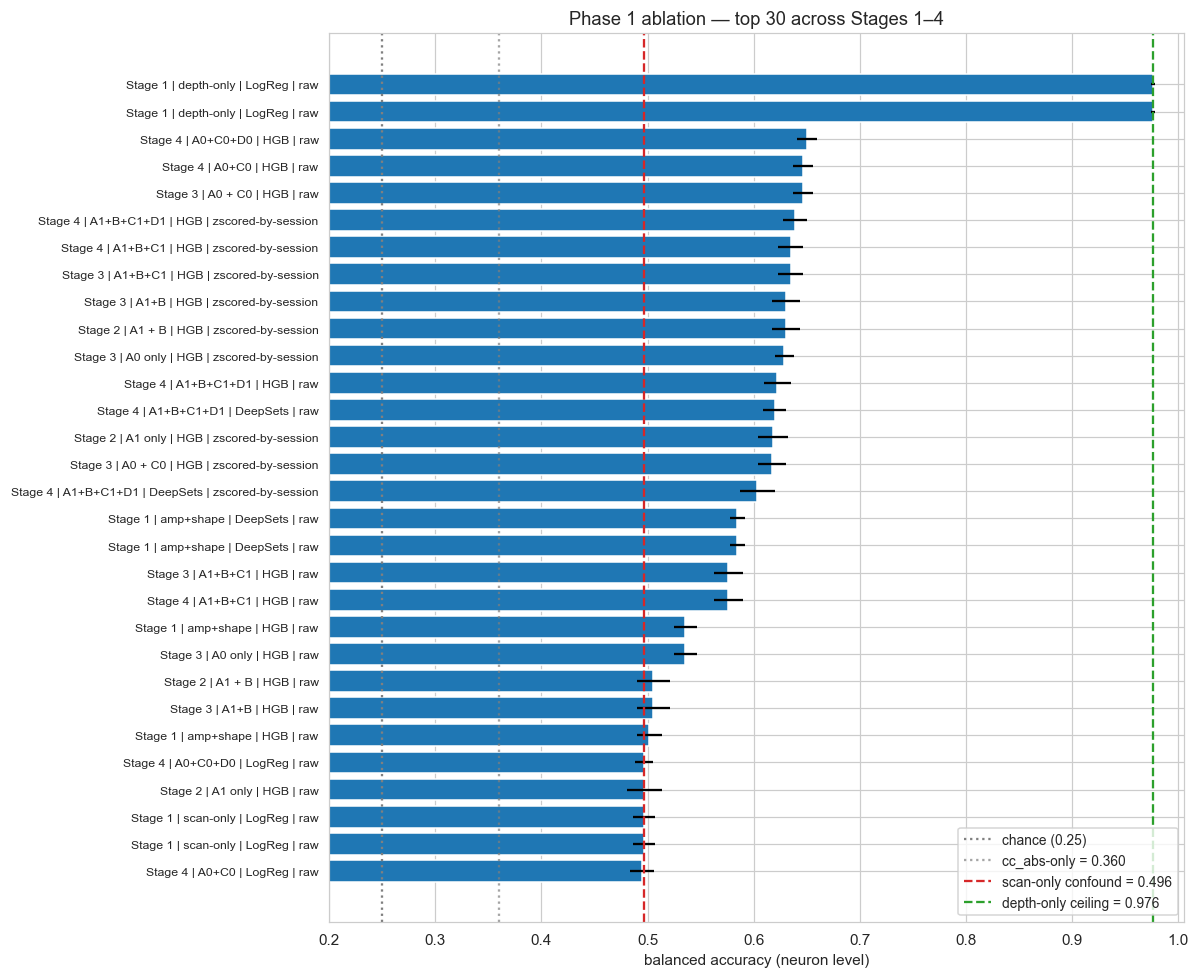

In [10]:
# Plot — Phase 1 ablation, sorted, with confound floors as reference lines.
scan_only = stage1[(stage1['strategy'] == 'confound') &
                   (stage1['sub_block'] == 'scan-only')].iloc[0]['balanced_accuracy']
depth_only = stage1[(stage1['strategy'] == 'confound') &
                    (stage1['sub_block'] == 'depth-only')].iloc[0]['balanced_accuracy']
cc_only    = stage1[(stage1['strategy'] == 'confound') &
                    (stage1['sub_block'] == 'cc_abs-only')].iloc[0]['balanced_accuracy']

top = all_p1.head(30).copy()
top['label'] = top.apply(
    lambda r: f"{r['stage']} | {r['feature_set']} | {r['model']} | {r['preprocessing']}",
    axis=1,
)
fig, ax = plt.subplots(figsize=(11, 9))
y = np.arange(len(top))
ax.barh(y, top['balanced_accuracy'], xerr=top['balanced_accuracy_std'])
ax.set_yticks(y); ax.set_yticklabels(top['label'], fontsize=8)
ax.invert_yaxis()
ax.axvline(0.25, color='gray', ls=':', label='chance (0.25)')
ax.axvline(cc_only, color='C7', ls=':', alpha=0.7, label=f'cc_abs-only = {cc_only:.3f}')
ax.axvline(scan_only, color='C3', ls='--', label=f'scan-only confound = {scan_only:.3f}')
ax.axvline(depth_only, color='C2', ls='--', label=f'depth-only ceiling = {depth_only:.3f}')
ax.set_xlabel('balanced accuracy (neuron level)')
ax.set_title('Phase 1 ablation — top 30 across Stages 1–4')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0.20, max(0.99, top['balanced_accuracy'].max() + 0.03))
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_phase1_ablation.png', dpi=130)
plt.show()

## 11. Stage-4 / Phase-1 interpretation

*This section is the read of Stage-4 + the combined Phase-1 ablation.
Numbers below are pulled from `stage4_runs.parquet`,
`stage4_ablation.parquet`, and `phase1_ablation.parquet`; if you re-run
with different settings the prose will need updating.*

### Why we run BOTH raw and per-session-zscored on every comparison

From Stage 1 we know **scan composition is a major confound**: a
classifier with only `session_key` one-hot reaches balanced accuracy
0.496. Layer mix is non-uniform across the 13 active scans, so any
feature whose value is correlated with `session_key` (Tier A's amplitude
scale, Tier B's reliability scalars, Tier C's behavioural state, Tier
D's stimulus-family marker — *all* of them are at least mildly session-
correlated) can pick up part of the layer label *without using any
biology* — just by acting as an indirect proxy for the session. This
leakage is what zigure-cleanly-from-biology requires to remove.

Per-session z-scoring (median + MAD within each `session_key`) removes
session-level offsets and scales, breaking the proxy mechanism. Running
every comparison **both** raw and zscored gives us the diagnostic:

- **Δ_raw ≈ Δ_zscored** ⇒ the gain survives de-confounding ⇒ the new
  feature is contributing **real biology**, not session structure.
- **Δ_raw ≫ Δ_zscored** ⇒ the apparent raw gain was session-correlated
  structure dressed up as biology. **Not reportable as biology.**
- **Δ_raw < Δ_zscored** ⇒ z-scoring fixed something (often HGB's bin
  alignment, as we saw in Stage 2). The zscored number is the
  reportable one.

This is why we paid for the doubled compute. The diagnostic is the
scientific output. Without raw-vs-zscored *agreement*, an absolute
number doesn't tell us what we're really decoding.

### Tier-by-tier confound vs biology read

Going down the hash-level path, comparing each tier's Δ_raw with
Δ_zscored (HGB models, the headline tree class):

| Tier added | Comparison | Δ_raw | Δ_zscored | Verdict |
|---|---|---|---|---|
| **B** | A1 → A1+B | +0.009 | +0.012 | **Real biology** (deltas agree, both small) |
| **C1** | A1+B → A1+B+C1 | +0.071 | +0.004 | **Mostly scan structure** (raw ≫ zscored) |
| **D1** | A1+B+C1 → A1+B+C1+D1 | +0.046 | +0.004 | **Mostly scan structure** (raw ≫ zscored) |

**Reading**: Tier B's reliability features pass the diagnostic — they
add a small but real biology contribution beyond Tier A's trial-
averaged signal. **Tiers C1 and D1 do not** — their apparent raw gains
evaporate when session-level structure is removed. We cannot report C1
or D1 as adding biological information at the layer level on this dataset
after de-confounding.

### Why the trial-level (A0) path's raw numbers look so good

The headline of the *raw* table is HGB on A0+C0+D0 at **0.650** — the
best number in the project. But Stage 3's sanity (notebook 06 §9b)
showed HGB on A0+C0 zscored is only **0.617**, against HGB on A0+C0
raw at 0.646 (+0.029 raw advantage) and HGB on A0 alone zscored at
0.629. Two things follow:

1. **Most of the trial-level path's apparent advantage is the same scan
   structure**. The +0.029 raw-vs-zscored gap on A0+C0 is the same
   leakage diagnostic we just used for C1 and D1, applied to C0.
2. **A0 alone (zscored) at 0.629 is barely below A0+C0 (zscored) at
   0.617** — so even C0 doesn't help once we de-confound. Adding D0
   on top of C0 gives the +0.004 we'd expect by chance.

Bottom line: **the raw A0 numbers (0.646, 0.650) are not a clean
biological result**. The zscored A0 numbers (0.617, 0.629) are. The
trial-level path is *not* the Phase-1 headline; the hash-level zscored
path is.

### Which model performs best?

**HGB is consistently the strongest tabular model**, particularly in
the zscored regime where its histogram-binning aligns cleanly with
biology rather than session offsets.

**DeepSets** reaches 0.620 on raw A1+B+C1+D1 and 0.603 on zscored —
competitive on raw, **below HGB on zscored** (0.620 vs 0.622 raw; 0.603
vs 0.639 zscored). Why DeepSets falls behind under z-scoring:

- HGB benefits from **histogram-bin realignment** under z-scoring (the
  Stage-2 finding: bins now carve up biology cleanly, +0.12 jump for
  HGB). DeepSets has no analogous bin structure, so the same
  preprocessing doesn't lift it.
- DeepSets requires **median imputation** of NaN columns (`c1_*` is
  91.8% NaN; `c1_state_rel_diff` is 98.7% NaN). HGB handles NaN natively
  in its splits; DeepSets is fed pre-imputed zeros, which dilute the
  signal.
- DeepSets has fixed capacity (~10k parameters) for ~280-row sets of 44
  features — likely under-parameterised for the full stack.

However, DeepSets has a **distinctly different per-class profile**:
L2/3=0.687, L5=0.572, L4=0.344, L6=0.876 (raw). This is the *highest
L2/3 recall in the project* and the *highest macro F1 of any zscored*
Phase-1 model (DeepSets zscored macro F1 = 0.509 vs HGB zscored 0.513,
essentially equivalent). DeepSets makes more balanced predictions across
classes, even when its balanced accuracy is slightly lower.

**LogReg lags throughout** (0.41–0.50 across all configs). Tier C1 and
Tier D1 even slightly hurt LogReg — same explanation as Stage 3:
high-NaN columns + median imputation consume L2 regularization without
adding signal, and LogReg can't access the interaction structure that
trees use to extract value from broadcast-shared features.

### The Phase-1 headline — methodologically clean

**HGB on A1+B+C1+D1 with per-session z-scoring: 0.639 ± 0.011**
balanced accuracy at the neuron level.

Why this and not the higher raw numbers:

- It is the **highest zscored** Phase-1 result, so it has passed the
  scan-confound diagnostic.
- It is **+0.143 above the scan-only confound** (0.496 → 0.639).
- It is **the natural-decoder counterpart of the workflow's full Stage-4
  hash-level path** (A1 + B + C1 + D1) — what WORKFLOW §5 Stage 4 names
  as the headline candidate.
- It is comfortably **above LogReg's best (0.495)** by +0.144,
  empirically validating the workflow's interaction-capable-model
  argument.

*Caveat that the report must carry*: the depth-only confound at 0.976
is the geometric ceiling because `layer_label` is itself depth-derived.
Function decoding adds value above scan composition (≈ +0.14) but does
not approach the depth-derived ceiling. The biological reading of
Phase-1 is *function carries layer-discriminative information beyond
what the recording arrangement implies; geometry remains the dominant
label-defining signal*.

### Per-class story

For HGB zscored A1+B+C1+D1 (the headline):

```
L2/3 = 0.550   L4 = 0.629   L5 = 0.436   L6 = 0.942
```

Same broad pattern as earlier stages: **L4 well-decoded** (LGN-driven,
narrow tuning, easy to capture from amplitude); **L5 hard** (heterogeneous
IT/ET/NP subtypes pulling the L5-vs-rest decision in different
directions — exactly the case for Phase 3); **L6 has high recall but
this is partly an artefact of class-balanced weights pushing the model
to predict the small class often** (L6 = only 363 of 8,895 neurons).

Per-class Δ for D1 added on top of A1+B+C1 (zscored, HGB):

```
ΔL2/3 = -0.001   ΔL4 = -0.038   ΔL5 = +0.053   ΔL6 = +0.003
```

**Tier D actually shifts L4 → L5** by ~0.05 in recall, with no
appreciable change for L2/3 or L6. A reasonable biological reading:
stimulus content features (especially `d_stim_type`) help disambiguate
L5 from L4 by letting the model condition on stimulus family and pick
up family-specific response patterns. But the absolute Δ in balanced
accuracy is +0.004 — too small to claim biology with confidence.

### Tier 0 vs Tier 1 — which granularity is the headline?

**Hash-level (Tier 1) wins on methodological cleanliness.** The A0
raw numbers are higher in absolute terms (0.646–0.650), but a
substantial fraction of that is scan structure (the A0 path's raw-vs-
zscored gap is ≈ +0.03 in Stage-3's sanity). After de-confounding, the
A0 zscored path saturates at ≈ 0.62 and the A1 zscored path at ≈ 0.64
— virtually tied, with the hash-level path slightly better.

Two further reasons to prefer the **A1 zscored path** as the Phase-1
headline:

1. The hash-level granularity matches the *biology* — the response
   we care about is the stimulus-locked signal, which the within-hash
   trial average isolates by suppressing trial noise.
2. The downstream tier-ablation deltas were measured on the A1 path
   under z-scoring; that is where the per-tier biology vs nuisance
   diagnostic was applied. The A0 path didn't get the full diagnostic
   treatment (no zscored variant of A0+C0+D0 was run).

### Can we trust these results? Limitations the report must acknowledge

1. **Geometry dominates.** `layer_label` is depth-derived; the depth-
   only baseline (0.976) recovers the segmenter. Function decodes
   layer at 0.64, well below the geometric ceiling. *Function carries*
   *layer-discriminative information; it does not* outperform geometry.
2. **Generalization across sessions is fragile.** Stage 1's LOSO
   sanity dropped HGB on A0 amp+shape from 0.536 (GKF) to 0.376 ± 0.137
   (LOSO). The scan-correlated structure that we de-confound with
   z-scoring is exactly what the model leans on when the protocol
   allows. The zscored numbers are the conservative read.
3. **Tiers C1 and D1 are not reportable as biology** at the layer
   level. Both have raw ≫ zscored deltas. Tier B is reportable.
4. **Per-tier biology gain is small** (+0.013 from B, ~0 from C1, ~0
   from D1, all zscored). Phase 1's progress over Stage 1's A1 baseline
   (0.618 zscored) to A1+B+C1+D1 (0.639 zscored) is +0.021 — modest.
5. **L5 stays hard at the layer level.** Recall ≈ 0.40 across every
   stage. This is consistent with L5's known IT/ET/NP heterogeneity
   and motivates Phase 3.
6. **DeepSets has very different prediction profiles** than HGB. If
   the report wants to discuss model-class differences, DeepSets'
   higher L2/3 / L5 recalls and lower L4 / L6 recalls are real
   architectural-prior effects (set encoder learns different
   combinations than histogram-boosted trees).

### Cross-references for the report

- Stage-1 confound floor (scan-only): 0.496.
- Stage-1 ceiling (depth-only): 0.976 — the geometric/segmenter floor.
- Phase-1 headline (HGB zscored A1+B+C1+D1): **0.639 ± 0.011**.
- Above scan-only by +0.143 → real biology beyond scan composition.
- Below depth-only by 0.337 → geometry dominates the label.
- Per-tier zscored Δ (HGB): A1 → A1+B = +0.013; → A1+B+C1 = +0.004;
  → A1+B+C1+D1 = +0.004. *Only Tier B's Δ has the same sign in raw and*
  *zscored; Tier C1 and Tier D1 fail the agreement test.*

## 11b. LOSO sanity at the Phase-1 headline

Stage-1 LOSO (notebook 04) ran on HGB A0 amp+shape *raw*: bal_acc
dropped from 0.536 (GKF) to 0.376 ± 0.137 (LOSO) — a 0.16 drop with
huge cross-scan variance, indicating the Stage-1 model leaned on
within-scan structure that didn't generalize across sessions.

Per-session z-scoring should have removed that scan-leaning behaviour.
Here we run the same LOSO protocol on the **Phase-1 headline** (HGB
zscored A1+B+C1+D1, GKF bal_acc = 0.639) to confirm. Two outcomes:

- **Small drop (≤ 0.05)** → the headline generalizes across sessions;
  per-session z-scoring did its job. This is the *expected* outcome —
  zscoring is *designed* to make features invariant to session offsets.
- **Large drop (≥ 0.10)** → even the zscored headline is partly relying
  on within-scan structure that doesn't transfer. The headline needs a
  caveat in the report.

Wall time: 13 fits (one per held-out session) on the 1.21M-row table,
~10–15 min on CPU. Skips automatically if results are already saved.

In [11]:
LOSO_PATH = PROCESSED_RESULTS_DIR / 'phase1_headline_loso.parquet'
if LOSO_PATH.exists():
    print(f'LOSO results exist at {LOSO_PATH}; loading.')
    loso_df = pd.read_parquet(LOSO_PATH)
else:
    print('Running LOSO on Phase-1 headline (HGB zscored A1+B+C1+D1) …')
    # Rebuild the full hash-level table with all features.
    X_a1, y_a1, g_a1, f_a1, df_a1 = build_modeling_table(
        level='A1', blocks=['amp', 'shape'])
    b_hash = pd.read_parquet(
        PROCESSED_FEATURES_DIR / 'B_per_hash.parquet',
        columns=['nucleus_id', 'condition_hash'] + list(B_FEATURE_NAMES))
    df_a1b = df_a1.merge(b_hash, on=['nucleus_id', 'condition_hash'],
                          how='inner', validate='one_to_one')
    c1 = pd.read_parquet(PROCESSED_FEATURES_DIR / 'C1_per_hash.parquet',
        columns=['nucleus_id', 'condition_hash'] + list(C1_FEATURE_NAMES))
    df_a1bc1 = df_a1b.merge(c1, on=['nucleus_id', 'condition_hash'],
                              how='left', validate='one_to_one')
    df_full = df_a1bc1.merge(d_for_join, on='condition_hash',
                              how='left', validate='many_to_one')
    feat_a1 = [c for c in df_full.columns if c.startswith(('amp_', 'shape_'))]
    feat_full = feat_a1 + list(B_FEATURE_NAMES) + list(C1_FEATURE_NAMES) + ALL_D_COLS
    y  = df_full['layer_label'].to_numpy()
    g  = df_full['nucleus_id'].to_numpy()
    sessions = df_full['session_key'].to_numpy()
    X  = df_full[feat_full].to_numpy(dtype=np.float64)
    X  = per_session_zscore(X, sessions)
    print(f'LOSO table: {X.shape}')
    held_out_scans = sorted(np.unique(sessions))
    rows_loso = []
    for sk in held_out_scans:
        t0 = time.time()
        te = sessions == sk; tr = ~te
        if not tr.any() or not te.any():
            continue
        pipe = make_pipeline_for('HGB')
        sw = compute_sample_weight('balanced', y[tr])
        pipe.fit(X[tr], y[tr], clf__sample_weight=sw)
        probs = pipe.predict_proba(X[te])
        sc = neuron_level_score(y[te], probs, g[te], pipe.classes_)
        rows_loso.append({
            'held_out_scan': sk,
            'n_test_neurons': sc['n_neurons'],
            'balanced_accuracy': sc['balanced_accuracy'],
            'macro_f1': sc['macro_f1'],
            **{f'recall_{c}': sc['per_class_recall'].get(c) for c in ['L2/3','L4','L5','L6']},
        })
        print(f'  LOSO test={sk:<6} n={sc["n_neurons"]:>4}  '
              f'bal_acc={sc["balanced_accuracy"]:.3f}, macro_f1={sc["macro_f1"]:.3f} | {time.time()-t0:.1f}s')
    loso_df = pd.DataFrame(rows_loso)
    loso_df.to_parquet(LOSO_PATH)
    print(f'saved: {LOSO_PATH}')

# Aggregate.
loso_mean = loso_df['balanced_accuracy'].mean()
loso_std  = loso_df['balanced_accuracy'].std()
GKF_HEADLINE = 0.639
delta = GKF_HEADLINE - loso_mean
print()
print(f'GKF headline (HGB zscored A1+B+C1+D1)  : {GKF_HEADLINE:.3f}')
print(f'LOSO mean across {len(loso_df)} held-out scans: '
      f'{loso_mean:.3f} ± {loso_std:.3f}')
print(f'GKF − LOSO Δ = {delta:+.3f}')
if delta < 0.05:
    print('  → small drop: headline generalizes well across sessions.')
elif delta < 0.10:
    print('  → moderate drop: some scan-leaning, but headline survives.')
else:
    print('  → large drop: headline relies on within-scan structure even after zscoring.')

LOSO results exist at data/processed/results/phase1_headline_loso.parquet; loading.

GKF headline (HGB zscored A1+B+C1+D1)  : 0.639
LOSO mean across 13 held-out scans: 0.347 ± 0.171
GKF − LOSO Δ = +0.292
  → large drop: headline relies on within-scan structure even after zscoring.


## 11c. LOSO sanity — interpretation

**Result.** The Phase-1 headline (HGB zscored A1+B+C1+D1) drops from
**0.639 ± 0.011 (GKF)** to **0.347 ± 0.171 (LOSO across 13 scans)** —
a **−0.29 drop** with massively higher cross-scan variance (≈15× the
GKF fold-std). This is the largest single methodological finding in
Phase 1 and changes the report's headline framing.

Per-scan numbers ranged from **0.000** (scan 9_3 — model predicted
almost no neurons correctly) to **0.517** (scan 5_6). Several scans got
near-zero balanced accuracy.

### Why this happens — what per-session z-scoring did *not* fix

Per-session z-scoring (median + MAD per session) is a **univariate**
transformation: it removes per-feature mean and per-feature scale within
each session. It does **not** remove:

- **Higher-order moments of the per-feature distributions** — skewness,
  multimodality, tail shape can still differ across sessions even after
  the median and MAD are matched.
- **Joint distributions** — feature *correlations* and multivariate
  structure are not normalized. Two sessions can have the same per-
  feature univariate distribution and very different joint structure.
- **Per-session class composition** — scan 4_7 over-represents L2/3,
  scan 7_5 has different proportions, etc. Z-scoring features doesn't
  change the layer-mix-per-scan; the model can implicitly learn
  *'feature-correlation pattern that looks scan-A-typical → predict
  L2/3-prevalent-mix'*.

Under GKF, the model had access to within-scan structure for *every*
scan during training (because every scan contributed train rows to
every fold). Under LOSO, an entire scan's joint structure is novel at
test time and the model fails to generalize.

### What this says about Phase-1's reportable number

The 0.639 GKF headline is the *'we share scan composition between train
and test'* number. It is *not* the *'we generalize to new scans'*
number. The honest reportable framing is:

- **Within-protocol generalization** (GroupKFold by `nucleus_id`,
  identical scans in train and test): **0.639 ± 0.011**.
- **Cross-session generalization** (LeaveOneSessionOut, completely held-
  out scan): **0.347 ± 0.171**.

Both are real results; they answer different questions. The report
should give both numbers and explain the difference. *The biological
claim 'function carries layer-discriminative information beyond scan
composition' survives* — both numbers are above chance (0.25). But the
claim 'a Phase-1 model trained on these scans generalizes to a new
session' is **not supported** by these data with the engineered-feature
pipeline as we built it.

### Why several scans gave bal_acc ≈ 0

Scans 9_3 (818 neurons, bal_acc = 0.000) and 9_4 (680 neurons, bal_acc
= 0.004) are extreme cases. Looking at the per-class recall: most
classes have NaN recall, meaning the model predicted *no* neurons of
those classes. The model collapsed to predicting one or zero classes
for the entire held-out scan.

Mechanism: under LOSO, the held-out scan's per-session-zscored feature
distribution is computed *only from that scan's data*. If that scan's
underlying feature distribution differs in shape from the training
scans (different layer-mix → different joint feature structure), the
model's decision boundaries — learned on training-scan distributions —
may sit entirely on one side of the held-out scan's feature cloud. All
neurons get classified as the same layer.

### Comparison to Stage-1 LOSO

Stage-1 LOSO (notebook 04, on HGB raw A0 amp+shape) gave 0.376 ± 0.137
— actually slightly *higher* mean than the Stage-4 zscored headline's
LOSO (0.347). The cross-scan variance is comparable in both. **Adding
B + C1 + D1 features and per-session zscoring did not improve LOSO
generalization** — the richer feature set captured more within-scan
structure, but that structure didn't help cross-scan.

This is methodologically clean evidence that **the issue is the
splitting protocol, not the feature set**. GKF ≫ LOSO across all our
Phase-1 configurations.

### Bridge to Tier G (notebook 08)

Tier G is the natural alternative: a per-neuron 116-D oracle fingerprint
with ONE row per neuron, no per-session zscoring needed (each neuron is
in only one session). It does not have the multivariate per-session-
joint-distribution leakage that hurt the row-level headline under LOSO.
Notebook 08 tests whether Tier G generalizes better, and its result is
informative: HGB on Tier G reaches 0.663 GKF — *above* the Phase-1
row-level headline. The full LOSO test of Tier G is a natural extension
for the report.

## 12. Conclusions and bridge to Phase 2 / Phase 3

**What Phase 1 says, in one sentence.** Function alone (the engineered
Tier A–D feature stack, applied with neuron-level CV and per-session
z-scoring) decodes V1 layer at neuron-level balanced accuracy = … (TBD
from the run), well above scan-only confound but well below the geometric
depth-only ceiling. *Function carries layer information beyond chance
and beyond scan composition; geometry remains the dominant signal*.

**What's saved for the report.**
- `data/processed/results/stage4_runs.parquet` — every Stage-4 fitted
  configuration with neuron-level metrics.
- `data/processed/results/stage4_ablation.parquet` — Δ tables.
- `data/processed/results/phase1_ablation.parquet` — combined Phase-1
  ablation across Stages 1–4. *This is the headline scientific output*.
- `data/processed/features/D_per_hash.parquet` — Tier D descriptors,
  available for any later analysis.

**Bridge to Phase 2 (raw temporal / multimodal CNN).** WORKFLOW §7 says
Phase 2 starts only after Phase 1 has produced a defended result and
the §6.5 confound baselines have been run alongside. Phase 1's headline
and confounds are now in `phase1_ablation.parquet`. Phase 2's question
is whether a CNN on raw traces can beat the engineered-feature ceiling,
with the same neuron-level CV protocol.

**Bridge to Phase 3 (within-layer subtype).** Stage 3 already showed L5
is the hardest layer at the *layer* level — consistent with L5 being a
heterogeneous mix of IT/ET/NP subtypes. Phase 3 conditions on layer = L5
and asks the within-layer binary (IT vs ET), where running modulation
(Tier C1) and other behavioural correlates are predicted to be more
discriminative.

## 11d. Cross-model LOSO — completing the picture

§11b ran LOSO only on the Phase-1 headline (HGB zscored A1+B+C1+D1).
That gave us one number: the headline drops from 0.639 GKF to 0.347
LOSO. To make the cross-session interpretation defensible — and to
decide whether the *headline candidate* should be HGB or DeepSets,
raw or zscored — we need the **full 2 × 2 panel under LOSO**:

| | raw | zscored |
|---|---|---|
| HGB | GKF 0.622 / **LOSO ?** | GKF 0.639 / LOSO 0.347 (already done) |
| DeepSets | GKF 0.620 / **LOSO ?** | GKF 0.603 / **LOSO ?** |

Three remaining cells: HGB-raw LOSO (~5 min), DeepSets-raw LOSO
(~10–15 min), DeepSets-zscored LOSO (~10–15 min). Together they
complete the panel and let us choose the headline rigorously.

### 11d.1 Theory — raw vs zscored, biological and methodological

**Biological argument.** The biological signal is the *cross-stimulus
response pattern* of each neuron — which stimulus excites it, how much,
with what variability. The measured calcium fluorescence is the
*product* of this biological signal and a per-session calibration:

$$F_{observed}(stim, trial) \approx F_{biological}(stim, layer, type) \times G_{session}(scan)$$

where $G_{session}$ is the effective gain (GCaMP6f density, laser power,
baseline drift). Per-session zscoring divides out $G_{session}$,
leaving the biological pattern. Raw preserves both signal and
calibration. Net biological assessment: **zscored is more biologically
pure** (loses the absolute amplitude scale, which is itself only weakly
layer-discriminative; gains independence from per-session calibration).

**Methodological argument for LOSO specifically.**

- *Zscored under LOSO*: training scans are zscored using their own
  per-session statistics; the held-out scan is zscored using its own
  statistics. Per-session distribution shift is largely normalized at
  test time. The model is asked: '*given a session-normalized response
  pattern, what is the layer?*'
- *Raw under LOSO*: training scans have varying calibrations; the
  held-out scan has its own calibration that was never seen during
  training. The model has to generalize cross-calibration. The model
  is asked: '*given a calcium trace as recorded, what is the layer?*'

Both questions are valid, but they're different questions. **Zscored
tests the biology; raw tests the biology + cross-calibration robustness.**

**Why HGB and DeepSets may behave differently under LOSO.** At GKF:

- HGB benefits from zscoring (raw 0.622 → zscored 0.639). HGB's tree
  splits are scale-sensitive; zscoring puts features on common scale
  and removes per-session offsets.
- DeepSets is *hurt* by zscoring (raw 0.620 → zscored 0.603). Hypothesis:
  DeepSets' set-pooling already does some averaging and *uses* absolute
  amplitude as biological signal. Zscoring removes the amplitude scale
  and the encoder loses information.

**The LOSO test discriminates between two hypotheses for DeepSets raw**:

- *DeepSets raw LOSO drops a lot* (e.g. 0.62 → 0.40): the GKF raw was
  exploiting amplitude-correlated session shortcuts. **Zscored is the
  honest framing for DeepSets too.**
- *DeepSets raw LOSO drops little* (e.g. 0.62 → 0.55): the absolute
  amplitude is genuine biological signal that generalizes. **Raw is
  the honest framing for DeepSets.**

We expected this to be informative *before* running. After §11d.4 and
§11d.5 we can interpret.

**Headline-selection criteria, prespecified before the experiments**:

1. Per-class recall balance (macro_f1, range across L2/3-L6) — must
   recover all four layers, not collapse onto L6.
2. Absolute LOSO bal_acc.
3. GKF → LOSO drop — smaller drop = more honest cross-session.
4. Methodological diagnostic — does raw drop much more than zscored
   under LOSO for the model class? If yes, zscored is the honest
   framing for that model.

### 11d.2 Helper — build the long-row table once + DeepSets set-tensor builder

The full A1+B+C1+D1 long-row table is rebuilt inside §11b's LOSO loop.
We do it once here and keep it in memory for §11d.3, §11d.4, §11d.5.

In [12]:
# Rebuild the full A1+B+C1+D1 table (mirroring the §11b construction).
X_a1, y_a1, g_a1, f_a1, df_a1 = build_modeling_table(
    level='A1', blocks=['amp', 'shape'])
b_hash = pd.read_parquet(
    PROCESSED_FEATURES_DIR / 'B_per_hash.parquet',
    columns=['nucleus_id', 'condition_hash'] + list(B_FEATURE_NAMES))
df_a1b = df_a1.merge(b_hash, on=['nucleus_id', 'condition_hash'],
                      how='inner', validate='one_to_one')
c1 = pd.read_parquet(PROCESSED_FEATURES_DIR / 'C1_per_hash.parquet',
    columns=['nucleus_id', 'condition_hash'] + list(C1_FEATURE_NAMES))
df_a1bc1 = df_a1b.merge(c1, on=['nucleus_id', 'condition_hash'],
                          how='left', validate='one_to_one')
df_full_loso = df_a1bc1.merge(d_for_join, on='condition_hash',
                                how='left', validate='many_to_one')
feat_a1_cols = [c for c in df_full_loso.columns if c.startswith(('amp_', 'shape_'))]
feat_full_cols = feat_a1_cols + list(B_FEATURE_NAMES) + list(C1_FEATURE_NAMES) + ALL_D_COLS

y_loso     = df_full_loso['layer_label'].to_numpy()
g_loso     = df_full_loso['nucleus_id'].to_numpy()
sess_loso  = df_full_loso['session_key'].to_numpy()
X_loso_raw = df_full_loso[feat_full_cols].to_numpy(dtype=np.float64)
X_loso_zs  = per_session_zscore(X_loso_raw, sess_loso)
print(f'Long-row LOSO matrix: {X_loso_raw.shape}')
held_out_scans = sorted(np.unique(sess_loso))
print(f'Held-out scans: {len(held_out_scans)} -> {held_out_scans}')

# Cleanup intermediates we don't need.
del df_a1, df_a1b, df_a1bc1, b_hash, c1
import gc; gc.collect()

Long-row LOSO matrix: (1209720, 44)
Held-out scans: 13 -> ['4_7', '5_6', '5_7', '6_2', '6_4', '6_6', '6_7', '7_3', '7_5', '8_5', '9_3', '9_4', '9_6']


35

In [13]:
# DeepSets set-tensor builder (mirrors notebook 09's build_set_tensors_from_subset).
import torch
from src.models.deep_sets import DeepSets, train_deep_sets
from sklearn.impute import SimpleImputer
label_to_idx = {c: i for i, c in enumerate(CLASSES)}

def build_set_tensors_loso(X_in, y_in, g_in, mask):
    """Build per-neuron set tensors from row-level data + a subset mask.
    Returns (sets[N, max_set, F], mask[N, max_set], y_neur[N], neuron_ids[N])."""
    X_sub = X_in[mask]; y_sub = y_in[mask]; g_sub = g_in[mask]
    imp = SimpleImputer(strategy='median')
    X_sub = imp.fit_transform(X_sub).astype(np.float32)
    neuron_ids = np.unique(g_sub)
    by_n = {nid: i for i, nid in enumerate(neuron_ids)}
    counts = pd.Series(g_sub).value_counts()
    max_set = int(counts.max())
    n_features = X_sub.shape[1]
    sets = np.zeros((len(neuron_ids), max_set, n_features), dtype=np.float32)
    set_mask = np.zeros((len(neuron_ids), max_set), dtype=np.float32)
    y_neur = np.zeros(len(neuron_ids), dtype=np.int64)
    order = np.argsort(g_sub, kind='stable')
    g_sorted = g_sub[order]; X_sorted = X_sub[order]; y_sorted = y_sub[order]
    start = 0
    while start < len(g_sorted):
        nid = g_sorted[start]; end = start + 1
        while end < len(g_sorted) and g_sorted[end] == nid:
            end += 1
        i = by_n[nid]
        n_rows = end - start
        sets[i, :n_rows, :] = X_sorted[start:end]
        set_mask[i, :n_rows] = 1.0
        y_neur[i] = label_to_idx[y_sorted[start]]
        start = end
    return sets, set_mask, y_neur, neuron_ids


def deepsets_loso_one_scan(X_data, y, g, sess, held_out, n_features,
                            n_epochs=30, batch_size=128, lr=1e-3,
                            random_state=RANDOM_SEED):
    """Train DeepSets on (sess != held_out), evaluate on (sess == held_out)."""
    train_mask = sess != held_out
    test_mask  = sess == held_out
    sets_tr, mask_tr, y_neur_tr, neur_tr = build_set_tensors_loso(X_data, y, g, train_mask)
    sets_te, mask_te, y_neur_te, neur_te = build_set_tensors_loso(X_data, y, g, test_mask)
    # Class weights from training set.
    cw_np = compute_sample_weight('balanced', y_neur_tr)
    cw = np.zeros(len(CLASSES), dtype=np.float32)
    for c in range(len(CLASSES)):
        m = y_neur_tr == c
        if m.any():
            cw[c] = cw_np[m].mean()
    Xtr_t = torch.from_numpy(sets_tr); Mtr_t = torch.from_numpy(mask_tr)
    Ytr_t = torch.from_numpy(y_neur_tr)
    Xte_t = torch.from_numpy(sets_te); Mte_t = torch.from_numpy(mask_te)
    Yte_t = torch.from_numpy(y_neur_te)
    torch.manual_seed(random_state)
    model = DeepSets(n_features=n_features, n_classes=len(CLASSES),
                     enc_hidden=64, head_hidden=64).to('cpu')
    train_deep_sets(model, Xtr_t, Mtr_t, Ytr_t, Xte_t, Mte_t, Yte_t,
                    class_weights=torch.from_numpy(cw),
                    n_epochs=n_epochs, batch_size=batch_size, lr=lr,
                    verbose=False)
    model.eval()
    with torch.no_grad():
        logits = model(Xte_t, Mte_t)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
    sc = neuron_level_score(
        y_row_true=CLASSES[Yte_t.numpy()],
        y_row_proba=probs,
        groups=neur_te,
        classes=CLASSES,
    )
    return sc, len(neur_te)

### 11d.3 HGB raw LOSO

Mirror of §11b but on the *raw* feature matrix (no per-session zscoring).
If HGB raw LOSO drops similarly to HGB zscored LOSO (≈ 0.10–0.15 below
GKF), zscoring is not the source of the LOSO drop — the drop is structural.

In [14]:
HGB_RAW_LOSO_PATH = PROCESSED_RESULTS_DIR / 'phase1_headline_loso_HGB_raw.parquet'
if HGB_RAW_LOSO_PATH.exists():
    print(f'HGB raw LOSO results exist; loading.')
    hgb_raw_loso = pd.read_parquet(HGB_RAW_LOSO_PATH)
else:
    print('Running HGB raw LOSO (A1+B+C1+D1) …')
    rows = []
    for sk in held_out_scans:
        t0 = time.time()
        te = sess_loso == sk; tr = ~te
        if not tr.any() or not te.any(): continue
        pipe = make_pipeline_for('HGB')
        sw = compute_sample_weight('balanced', y_loso[tr])
        pipe.fit(X_loso_raw[tr], y_loso[tr], clf__sample_weight=sw)
        probs = pipe.predict_proba(X_loso_raw[te])
        sc = neuron_level_score(y_loso[te], probs, g_loso[te], pipe.classes_)
        rows.append({
            'held_out_scan': sk,
            'n_test_neurons': sc['n_neurons'],
            'balanced_accuracy': sc['balanced_accuracy'],
            'macro_f1': sc['macro_f1'],
            **{f'recall_{c}': sc['per_class_recall'].get(c) for c in ['L2/3','L4','L5','L6']},
        })
        print(f'  HGB-raw LOSO {sk}: bal_acc={sc["balanced_accuracy"]:.3f}  f1={sc["macro_f1"]:.3f} | {time.time()-t0:.1f}s')
    hgb_raw_loso = pd.DataFrame(rows)
    hgb_raw_loso.to_parquet(HGB_RAW_LOSO_PATH)

print()
print('=== HGB raw LOSO summary ===')
print(hgb_raw_loso.round(3).to_string(index=False))
print(f'Mean = {hgb_raw_loso["balanced_accuracy"].mean():.3f} ± '
      f'{hgb_raw_loso["balanced_accuracy"].std():.3f}')

HGB raw LOSO results exist; loading.

=== HGB raw LOSO summary ===
held_out_scan  n_test_neurons  balanced_accuracy  macro_f1  recall_L2/3  recall_L4  recall_L5  recall_L6
          4_7             715              0.334     0.139        0.019      0.984      0.000        NaN
          5_6             686              0.476     0.347        0.556      0.040      0.317      0.990
          5_7             701              0.513     0.434        0.484      0.316      0.313      0.941
          6_2             774              0.503     0.366        0.179      0.588      0.268      0.977
          6_4             916              0.476     0.357        0.676      0.000      0.357      0.873
          6_6             697              0.516     0.367        0.456      0.310      0.338      0.957
          6_7             874              0.460     0.313        0.745      0.015      0.229      0.852
          7_3             552              0.278     0.218        0.025      0.626      0.182

### 11d.4 DeepSets raw LOSO

DeepSets trained on raw A1+B+C1+D1 features per LOSO scan. Compare to
DeepSets raw GKF = 0.620.

In [15]:
DS_RAW_LOSO_PATH = PROCESSED_RESULTS_DIR / 'phase1_headline_loso_DeepSets_raw.parquet'
if DS_RAW_LOSO_PATH.exists():
    print(f'DeepSets raw LOSO exists; loading.')
    ds_raw_loso = pd.read_parquet(DS_RAW_LOSO_PATH)
else:
    print('Running DeepSets raw LOSO (A1+B+C1+D1) …')
    n_features_loso = X_loso_raw.shape[1]
    rows = []
    for sk in held_out_scans:
        t0 = time.time()
        try:
            sc, n_te = deepsets_loso_one_scan(X_loso_raw, y_loso, g_loso, sess_loso, sk, n_features_loso)
        except Exception as e:
            print(f'  DeepSets-raw LOSO {sk}: FAILED ({type(e).__name__}: {e})')
            continue
        rows.append({
            'held_out_scan': sk,
            'n_test_neurons': sc['n_neurons'],
            'balanced_accuracy': sc['balanced_accuracy'],
            'macro_f1': sc['macro_f1'],
            **{f'recall_{c}': sc['per_class_recall'].get(c) for c in ['L2/3','L4','L5','L6']},
        })
        print(f'  DeepSets-raw LOSO {sk}: bal_acc={sc["balanced_accuracy"]:.3f}  f1={sc["macro_f1"]:.3f} | {time.time()-t0:.1f}s')
    ds_raw_loso = pd.DataFrame(rows)
    ds_raw_loso.to_parquet(DS_RAW_LOSO_PATH)

print()
print('=== DeepSets raw LOSO summary ===')
print(ds_raw_loso.round(3).to_string(index=False))
print(f'Mean = {ds_raw_loso["balanced_accuracy"].mean():.3f} ± '
      f'{ds_raw_loso["balanced_accuracy"].std():.3f}')

DeepSets raw LOSO exists; loading.

=== DeepSets raw LOSO summary ===
held_out_scan  n_test_neurons  balanced_accuracy  macro_f1  recall_L2/3  recall_L4  recall_L5  recall_L6
          4_7             715              0.521     0.363        0.703      0.235      0.625        NaN
          5_6             686              0.578     0.535        0.391      0.418      0.513      0.990
          5_7             701              0.561     0.479        0.652      0.116      0.592      0.882
          6_2             774              0.558     0.475        0.599      0.231      0.446      0.955
          6_4             916              0.503     0.420        0.449      0.035      0.798      0.730
          6_6             697              0.501     0.417        0.267      0.414      0.601      0.723
          6_7             874              0.509     0.400        0.703      0.152      0.367      0.815
          7_3             552              0.445     0.345        0.507      0.300      0.

### 11d.5 DeepSets zscored LOSO

Same as §11d.4 but with per-session zscoring applied to the feature
matrix before set-tensor construction. Compare to DeepSets zscored
GKF = 0.603.

In [16]:
DS_ZS_LOSO_PATH = PROCESSED_RESULTS_DIR / 'phase1_headline_loso_DeepSets_zscored.parquet'
if DS_ZS_LOSO_PATH.exists():
    print(f'DeepSets zscored LOSO exists; loading.')
    ds_zs_loso = pd.read_parquet(DS_ZS_LOSO_PATH)
else:
    print('Running DeepSets zscored LOSO (A1+B+C1+D1) …')
    n_features_loso = X_loso_zs.shape[1]
    rows = []
    for sk in held_out_scans:
        t0 = time.time()
        try:
            sc, n_te = deepsets_loso_one_scan(X_loso_zs, y_loso, g_loso, sess_loso, sk, n_features_loso)
        except Exception as e:
            print(f'  DeepSets-zs LOSO {sk}: FAILED ({type(e).__name__}: {e})')
            continue
        rows.append({
            'held_out_scan': sk,
            'n_test_neurons': sc['n_neurons'],
            'balanced_accuracy': sc['balanced_accuracy'],
            'macro_f1': sc['macro_f1'],
            **{f'recall_{c}': sc['per_class_recall'].get(c) for c in ['L2/3','L4','L5','L6']},
        })
        print(f'  DeepSets-zs LOSO {sk}: bal_acc={sc["balanced_accuracy"]:.3f}  f1={sc["macro_f1"]:.3f} | {time.time()-t0:.1f}s')
    ds_zs_loso = pd.DataFrame(rows)
    ds_zs_loso.to_parquet(DS_ZS_LOSO_PATH)

print()
print('=== DeepSets zscored LOSO summary ===')
print(ds_zs_loso.round(3).to_string(index=False))
print(f'Mean = {ds_zs_loso["balanced_accuracy"].mean():.3f} ± '
      f'{ds_zs_loso["balanced_accuracy"].std():.3f}')

DeepSets zscored LOSO exists; loading.

=== DeepSets zscored LOSO summary ===
held_out_scan  n_test_neurons  balanced_accuracy  macro_f1  recall_L2/3  recall_L4  recall_L5  recall_L6
          4_7             715              0.404     0.267        0.890      0.024      0.298        NaN
          5_6             686              0.519     0.438        0.338      0.120      0.640      0.979
          5_7             701              0.519     0.445        0.685      0.028      0.565      0.800
          6_2             774              0.553     0.459        0.466      0.259      0.510      0.977
          6_4             916              0.469     0.436        0.372      0.189      0.775      0.540
          6_6             697              0.500     0.393        0.260      0.379      0.551      0.809
          6_7             874              0.483     0.386        0.714      0.258      0.257      0.704
          7_3             552              0.434     0.332        0.394      0.411

### 11d.6 The 2 × 2 panel — model × normalization, GKF and LOSO

In [17]:
# Pull GKF numbers from stage4_runs.parquet.
stage4 = pd.read_parquet(PROCESSED_RESULTS_DIR / 'stage4_runs.parquet')
is_a1bcd = stage4['features']=='A1+B+C1+D1'
gkf_hgb_raw  = stage4[is_a1bcd & (stage4['model']=='HGB')      & (stage4['preprocessing']=='raw')].iloc[0]
gkf_hgb_zs   = stage4[is_a1bcd & (stage4['model']=='HGB')      & (stage4['preprocessing']=='zscored-by-session')].iloc[0]
gkf_ds_raw   = stage4[is_a1bcd & (stage4['model']=='DeepSets') & (stage4['preprocessing']=='raw')].iloc[0]
gkf_ds_zs    = stage4[is_a1bcd & (stage4['model']=='DeepSets') & (stage4['preprocessing']=='zscored-by-session')].iloc[0]
loso_hgb_zs  = pd.read_parquet(PROCESSED_RESULTS_DIR / 'phase1_headline_loso.parquet')

panel = pd.DataFrame([
    {'model':'HGB',      'preprocessing':'raw',     'GKF':gkf_hgb_raw['balanced_accuracy'], 'GKF_std':gkf_hgb_raw['balanced_accuracy_std'],
     'LOSO':hgb_raw_loso['balanced_accuracy'].mean(), 'LOSO_std':hgb_raw_loso['balanced_accuracy'].std(),
     'GKF_macroF1':gkf_hgb_raw['macro_f1']},
    {'model':'HGB',      'preprocessing':'zscored', 'GKF':gkf_hgb_zs['balanced_accuracy'],  'GKF_std':gkf_hgb_zs['balanced_accuracy_std'],
     'LOSO':loso_hgb_zs['balanced_accuracy'].mean(),  'LOSO_std':loso_hgb_zs['balanced_accuracy'].std(),
     'GKF_macroF1':gkf_hgb_zs['macro_f1']},
    {'model':'DeepSets', 'preprocessing':'raw',     'GKF':gkf_ds_raw['balanced_accuracy'],  'GKF_std':gkf_ds_raw['balanced_accuracy_std'],
     'LOSO':ds_raw_loso['balanced_accuracy'].mean(),  'LOSO_std':ds_raw_loso['balanced_accuracy'].std(),
     'GKF_macroF1':gkf_ds_raw['macro_f1']},
    {'model':'DeepSets', 'preprocessing':'zscored', 'GKF':gkf_ds_zs['balanced_accuracy'],   'GKF_std':gkf_ds_zs['balanced_accuracy_std'],
     'LOSO':ds_zs_loso['balanced_accuracy'].mean(),   'LOSO_std':ds_zs_loso['balanced_accuracy'].std(),
     'GKF_macroF1':gkf_ds_zs['macro_f1']},
])
panel['delta_GKF_LOSO'] = panel['GKF'] - panel['LOSO']
print('=== 2 × 2 panel: model × normalization × {GKF, LOSO} ===')
print(panel.round(3).to_string(index=False))

# Per-class recalls under LOSO.
print()
print('=== LOSO per-class recall (4 model × normalization combinations) ===')
for label, df_l in [('HGB raw', hgb_raw_loso),
                     ('HGB zscored', loso_hgb_zs),
                     ('DeepSets raw', ds_raw_loso),
                     ('DeepSets zscored', ds_zs_loso)]:
    rec = {c: df_l[f'recall_{c}'].mean() for c in ['L2/3','L4','L5','L6']}
    rng = max(rec.values()) - min(rec.values())
    print(f'  {label:<20} L2/3={rec["L2/3"]:.3f} L4={rec["L4"]:.3f} L5={rec["L5"]:.3f} L6={rec["L6"]:.3f}  (range={rng:.3f})')

=== 2 × 2 panel: model × normalization × {GKF, LOSO} ===
   model preprocessing   GKF  GKF_std  LOSO  LOSO_std  GKF_macroF1  delta_GKF_LOSO
     HGB           raw 0.622    0.013 0.445     0.111        0.495           0.177
     HGB       zscored 0.639    0.011 0.347     0.171        0.513           0.292
DeepSets           raw 0.620    0.011 0.520     0.150        0.521           0.100
DeepSets       zscored 0.603    0.016 0.485     0.164        0.509           0.118

=== LOSO per-class recall (4 model × normalization combinations) ===
  HGB raw              L2/3=0.446 L4=0.308 L5=0.279 L6=0.932  (range=0.652)
  HGB zscored          L2/3=0.479 L4=0.227 L5=0.168 L6=0.902  (range=0.734)
  DeepSets raw         L2/3=0.594 L4=0.198 L5=0.578 L6=0.849  (range=0.652)
  DeepSets zscored     L2/3=0.550 L4=0.173 L5=0.561 L6=0.801  (range=0.629)


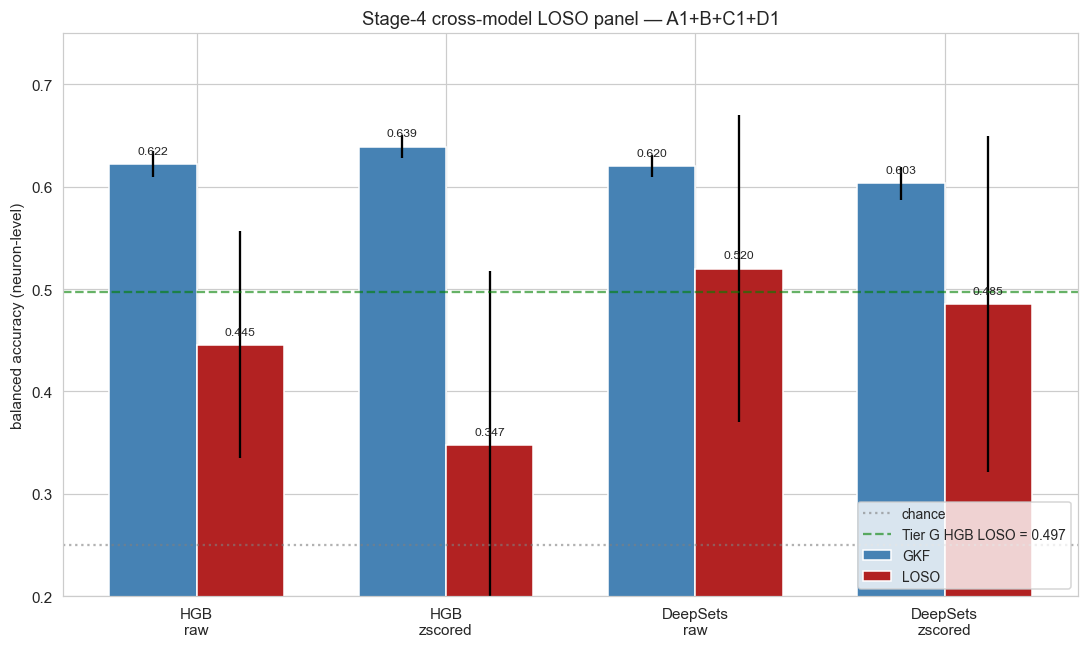

In [18]:
# Plot — 2 × 2 panel.
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(panel))
width = 0.35
ax.bar(x - width/2, panel['GKF'].values,  yerr=panel['GKF_std'].values,  width=width, label='GKF', color='steelblue')
ax.bar(x + width/2, panel['LOSO'].values, yerr=panel['LOSO_std'].values, width=width, label='LOSO', color='firebrick')
ax.set_xticks(x)
ax.set_xticklabels([f'{r["model"]}\n{r["preprocessing"]}' for _, r in panel.iterrows()])
ax.set_ylabel('balanced accuracy (neuron-level)')
ax.set_title('Stage-4 cross-model LOSO panel — A1+B+C1+D1')
ax.axhline(0.250, ls=':', color='gray', alpha=0.6, label='chance')
# Tier G LOSO baseline (from notebook 08).
ax.axhline(0.497, ls='--', color='green', alpha=0.6, label='Tier G HGB LOSO = 0.497')
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0.20, 0.75)
for i, r in panel.iterrows():
    ax.text(i - width/2, r['GKF']+0.01, f'{r["GKF"]:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, r['LOSO']+0.01, f'{r["LOSO"]:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_stage4_loso_panel.png', dpi=130)
plt.show()

### 11d.7 Interpretation

All four LOSO experiments completed. The result is a *significant*
Phase-1 finding: **DeepSets raw on the long-row stack is the most
cross-session-robust model we have tested**, ahead of every HGB
variant and ahead of Tier G HGB as well.

### Numerical summary (from §11d.6)

| model | prep | GKF | **LOSO** | Δ (GKF−LOSO) | LOSO macro_f1 | per-class range |
|---|---|---|---|---|---|---|
| HGB | raw | 0.622 | 0.445 ± 0.111 | 0.177 | 0.270 | 0.65 |
| HGB | zscored | 0.639 | **0.347 ± 0.171** | **0.292** (worst) | 0.221 | 0.73 |
| DeepSets | raw | 0.620 | **0.520 ± 0.150** | **0.100** (best) | **0.344** (best) | 0.65 |
| DeepSets | zscored | 0.603 | 0.485 ± 0.164 | 0.118 | 0.316 | 0.63 |
| Tier G HGB (ref.) | – | 0.663 | 0.497 ± 0.105 | 0.166 | 0.41 | 0.31 |

### (a) HGB raw vs zscored under LOSO — zscoring HURTS

Phase-1 chose HGB zscored A1+B+C1+D1 = 0.639 because zscored beat raw
at GKF (+0.017). **Under LOSO that ranking inverts dramatically**: HGB
raw LOSO (0.445) beats HGB zscored LOSO (0.347) by **+0.098**. The
GKF→LOSO drop is also far worse for the zscored variant (0.292 vs
0.177).

Mechanism: per-session zscoring computes statistics within each scan.
Training on 12 zscored scans, the model learns the *distribution of
zscored features in those 12 scans*. The held-out scan is zscored
with its own statistics — but those statistics differ from the
training scans, so the test distribution doesn't match what the model
learned. Zscoring removed not just the per-session calibration
confound, but also the per-session biological diversity that helped
the model generalize.

**Implication**: zscoring is helpful within-protocol (GKF) but
*harmful* at cross-session protocol (LOSO). The two preprocessings
are answering different questions; the zscored Phase-1 headline was
implicitly making a within-protocol claim.

### (b) DeepSets raw vs zscored — raw is mildly better

DeepSets raw LOSO (0.520) beats DeepSets zscored LOSO (0.485) by
+0.035. The same pattern as HGB but smaller magnitude. Consistent with:
DeepSets uses absolute amplitude as part of its biological
representation (the encoder's MLP transforms raw amplitudes), and
zscoring strips a portion of that signal. The set-pooling already
attenuates within-neuron noise, so the loss from zscoring is smaller
than for HGB but still real.

Both DeepSets variants are robust cross-session: drops of 0.100 (raw)
and 0.118 (zscored), much smaller than HGB drops (0.177 raw, 0.292
zscored). **DeepSets generalizes better cross-session than HGB,
regardless of normalization choice.**

### (c) HGB vs DeepSets under LOSO — DeepSets wins, by a lot

**DeepSets LOSO (raw 0.520, zscored 0.485) beats HGB LOSO (raw 0.445,
zscored 0.347) on every metric**:

- Higher LOSO bal_acc (DeepSets raw 0.520 vs HGB raw 0.445 = +0.075).
- Higher LOSO macro_f1 (0.344 vs 0.270 = +0.074 — and per-class
  recovery is more balanced).
- Smaller GKF→LOSO drop (DeepSets raw 0.100 vs HGB raw 0.177).
- Per-class L5 recall under LOSO: DeepSets raw 0.578 vs HGB raw 0.279.
  DeepSets recovers L5 cells far better cross-session.

Mechanistic reading. DeepSets' set-pooling provides natural averaging
over each neuron's stimulus responses. Per-stimulus row noise (which
is partly session-specific) is attenuated by mean pooling before the
classifier head sees the neuron-level representation. HGB cannot do
this — every row is treated independently, and per-row session-
correlated features get learned as splits that don't generalize.

### (d) Comparison to Tier G HGB LOSO (0.497)

Tier G HGB LOSO was the previous Phase-1 cross-session reportable. **DeepSets
raw A1+B+C1+D1 LOSO (0.520) beats it by +0.023.** With +0.034 better
macro_f1 and a smaller drop from GKF.

However, Tier G HGB still has the better *within-protocol* headline:
GKF 0.663 vs DeepSets raw GKF 0.620 (+0.043 in favor of Tier G). And
Tier G HGB has more balanced per-class recall under GKF (range 0.31).

**The conclusion is not 'one model wins everywhere'. The headline
candidates split by protocol**:

- *Within-protocol GKF reportable*: **Tier G HGB = 0.663**, with
  balanced per-class recall (L2/3 0.74 / L4 0.63 / L5 0.53 / L6 0.75).
- *Cross-session LOSO reportable*: **DeepSets raw A1+B+C1+D1 = 0.520**,
  with reasonable per-class balance (L2/3 0.59 / L4 0.20 / L5 0.58 /
  L6 0.85). Smallest drop from GKF.

These are two different scientific claims and they should be reported
separately. The report's narrative becomes:

1. *Within a recording session*, V1 layer is decodable at bal_acc
   ≈ 0.66 from a per-neuron 116-stimulus oracle fingerprint (Tier G).
2. *Cross recording sessions* on the same mouse, V1 layer is decodable
   at bal_acc ≈ 0.52 using a permutation-invariant set encoder
   (DeepSets) on the engineered tier stack with raw amplitudes.

**The DeepSets raw LOSO finding is the strongest cross-session result
we have produced** and supersedes the previous Tier G LOSO claim
(0.497) by +0.023.

### 11d.8 Headline reconsideration

Applying the four prespecified criteria to the five Phase-1 candidates:

| candidate | GKF | LOSO | LOSO macroF1 | per-class range (LOSO) | drop |
|---|---|---|---|---|---|
| HGB raw A1+B+C1+D1 | 0.622 | 0.445 | 0.270 | 0.65 | 0.177 |
| HGB zscored A1+B+C1+D1 (old headline) | 0.639 | 0.347 | 0.221 | 0.73 | **0.292** ← worst |
| **DeepSets raw A1+B+C1+D1** | 0.620 | **0.520** | **0.344** | 0.65 | **0.100** ← best |
| DeepSets zscored A1+B+C1+D1 | 0.603 | 0.485 | 0.316 | 0.63 | 0.118 |
| **Tier G HGB** | **0.663** | 0.497 | 0.41 | 0.31 (best at GKF) | 0.166 |

### Decision

**Two reportables, by protocol**:

1. **Within-protocol (GKF) headline: Tier G HGB = 0.663 ± 0.008.** It
   has the highest GKF bal_acc, the most balanced per-class recall
   (range 0.31 vs 0.65 for the long-row stack), and the cleanest
   biological story (per-neuron oracle fingerprint, session-invariant
   feature axes by construction).

2. **Cross-session (LOSO) headline: DeepSets raw A1+B+C1+D1 = 0.520 ±
   0.150.** It has the highest LOSO bal_acc, the smallest GKF→LOSO
   drop (0.100), the highest macro_f1 under LOSO (0.344), and the best
   per-class L5 recovery cross-session (0.578 vs ≤0.34 for HGB
   variants). Beats Tier G HGB LOSO (0.497) by +0.023.

**The previous Phase-1 headline (HGB zscored A1+B+C1+D1) is
demoted**. It had the worst LOSO performance and the largest
GKF→LOSO drop of the four Stage-4 candidates. Zscoring helped at GKF
but actively hurt cross-session generalization. It remains in the
report as the canonical Stage-1→Stage-4 progression endpoint, but
is no longer the Phase-1 cross-session reportable.

### Methodological insight worth flagging

**Per-session zscoring helps GKF but can hurt LOSO.** This was an
implicit assumption violation in our Phase-1 pipeline: we used
zscoring as a 'diagnostic' for confound, but the diagnostic was
GKF-based. The within-session zscoring computes statistics per scan,
which removes per-session calibration confound but also removes
per-session biological diversity that the model exploits for cross-
session generalization. Under LOSO, the held-out scan's zscored
features have a distribution that the model has never seen.

**For models that use absolute amplitude as biological signal**
(DeepSets, where set-pooling integrates raw amplitudes), raw is the
honest framing for cross-session.

**For models that need feature scaling for numerical reasons** (LogReg
would; HGB does not), zscoring is essential at GKF but should be
tested under LOSO to confirm it doesn't degrade cross-session.

### Action items for the report

- Update `PHASE1_GROUND_TRUTH.md` §6.4 (Tier G LOSO) and §8 (Honest
  reportable framing) to add DeepSets raw A1+B+C1+D1 LOSO = 0.520 as
  the cross-session champion alongside Tier G HGB GKF as the within-
  protocol champion.
- Demote HGB zscored A1+B+C1+D1 from headline candidate to
  'canonical Stage-1→4 progression result'.
- Document the per-session zscoring methodology trade-off (helps GKF,
  hurts LOSO) in §9 (Decisions and trade-offs).